# 🏎️ F1 Constructor-Centric Lap Time Prediction Model

> **Architecture**: Constructor-Centric XGBoost + LightGBM Regressors  
> **Training Data**: 2022–2024 (68 races, per-race FastF1 CSVs — 65 features)  
> **Holdout Test Set**: 2025 season (24 races — never touched during training)  
> **Design Philosophy**: Drivers change teams; the *car package* (constructor) is the stable pace determinant

## Rationale for Constructor-Centric Design

| Driver-Centric Approach | Constructor-Centric Approach (This Notebook) |
|---|---|
| Hamilton's 2024 lap times used to predict his 2025 Ferrari pace | Ferrari's 2022–2024 pace baseline predicts their 2025 pace |
| Breaks every time a driver changes team | Stable across driver transfers |
| High data sparsity per driver-circuit pair | Full grid coverage per constructor |
| Cannot handle rookies | Any driver in a known constructor is handled |

### Key differences from `Lap_Time_Prediction.ipynb` (v1)
- Uses **per-race CSVs** (`data_fastf1_v1/laps/`) with 65 columns vs consolidated CSV (21 cols)
- Adds **weather features** (AirTemp, TrackTemp, Humidity, Rainfall)
- Strict **safety car / VSC / out-lap / in-lap / deleted lap filtering**
- **Constructor harmonisation** maps team name changes to canonical identities
- Strict **GroupKFold CV** (grouped by race) prevents lap-level leakage
- Training restricted to **2022–2024** (ground-effect regulation era only)
- **SHAP explainability** and per-constructor error analysis


## Section 0 — Setup & Configuration


In [28]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 0: Setup & Configuration
# ─────────────────────────────────────────────────────────────────────────────
import os
import glob
import json
import warnings
import joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
import lightgbm as lgb
import shap

from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings('ignore')

# ── Plotting style ────────────────────────────────────────────────────────────
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except OSError:
    plt.style.use('ggplot')
plt.rcParams.update({'figure.figsize': (14, 6), 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})

# ── Path Configuration ────────────────────────────────────────────────────────
DATA_ROOT  = 'data_fastf1_v1/laps'
MODEL_OUT  = 'models/Lap Time Estimation v2'
OUTPUT_DIR = 'outputs/lap_time_v2'

os.makedirs(MODEL_OUT,  exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Year splits ───────────────────────────────────────────────────────────────
TRAIN_YEARS = [2022, 2023, 2024]
TEST_YEAR   = 2025
ALL_YEARS   = TRAIN_YEARS + [TEST_YEAR]

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print('✅ Environment initialised.')
print(f'   Training years : {TRAIN_YEARS}')
print(f'   Holdout year   : {TEST_YEAR}')
print(f'   Model output   : {MODEL_OUT}')


✅ Environment initialised.
   Training years : [2022, 2023, 2024]
   Holdout year   : 2025
   Model output   : models/Lap Time Estimation v2


## Section 1 — Data Loading & Audit

Load all per-race CSVs from `data_fastf1_v1/laps/{year}/{race}.csv` for 2022–2025.  
Each CSV has **65 columns** including weather, track-status flags, safety car indicators,  
and gap data — far richer than the consolidated CSV.


In [29]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 1: Data Loading & Audit
# ─────────────────────────────────────────────────────────────────────────────

dfs = []
load_log = []

for year in ALL_YEARS:
    pattern = os.path.join(DATA_ROOT, str(year), '*.csv')
    files = sorted(glob.glob(pattern))
    year_rows = 0
    for fpath in files:
        race_name = os.path.splitext(os.path.basename(fpath))[0].replace('_', ' ')
        try:
            df_race = pd.read_csv(fpath, low_memory=False)
            df_race['_source_file'] = race_name
            dfs.append(df_race)
            year_rows += len(df_race)
        except Exception as e:
            print(f'  WARNING: Failed to load {fpath}: {e}')
    load_log.append({'Year': year, 'Races': len(files), 'Laps': year_rows})
    print(f'  {year}: {len(files):>2} races | {year_rows:>6,} laps loaded')

df_raw = pd.concat(dfs, ignore_index=True)
print(f'\n📦 Raw dataset shape : {df_raw.shape}')
print(f'   Memory usage      : {df_raw.memory_usage(deep=True).sum() / 1e6:.1f} MB')

# ── Load summary ─────────────────────────────────────────────────────────────
print('\n📊 Per-Year Load Summary:')
display(pd.DataFrame(load_log).set_index('Year'))

# ── Null audit ───────────────────────────────────────────────────────────────
null_pct = (df_raw.isnull().sum() / len(df_raw) * 100).sort_values(ascending=False)
null_pct = null_pct[null_pct > 0]
print(f'\n  Columns with missing values ({len(null_pct)} columns):')
display(null_pct.to_frame('Null %').round(2))


  2022: 22 races | 23,577 laps loaded
  2023: 22 races | 24,420 laps loaded
  2024: 24 races | 26,604 laps loaded
  2025: 24 races | 26,689 laps loaded

📦 Raw dataset shape : (101290, 66)
   Memory usage      : 165.1 MB

📊 Per-Year Load Summary:


,Races,Laps
Year,,
2022,22,23577
2023,22,24420
2024,24,26604
2025,24,26689



  Columns with missing values (33 columns):


,Null %
LapStartDate,100.00
DeletedReason,98.74
PitOutTimeSeconds,96.58
PitOutTime,96.58
PitInTime,96.58
PitInTimeSeconds,96.58
GapToLeaderSeconds,14.25
IntervalToPositionAheadSeconds,5.62
SpeedFL,3.56
Sector1SessionTime,2.29


## Section 2 — Constructor Harmonisation

Team names changed multiple times across 2022–2025 due to rebranding and ownership changes.  
We map all variants to **canonical constructor names** so the model learns the car package pace, not brand labels.

| Raw Names | Canonical | Notes |
|---|---|---|
| AlphaTauri, RB, Racing Bulls | Racing Bulls | Red Bull junior team, same factory |
| Alfa Romeo Racing, Alfa Romeo, Kick Sauber, Sauber | Sauber | Title sponsor changes only |
| All others | unchanged | Red Bull Racing, Ferrari, Mercedes, McLaren, Aston Martin, Alpine, Williams, Haas |


In [30]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 2: Constructor Harmonisation
# ─────────────────────────────────────────────────────────────────────────────

CONSTRUCTOR_MAP = {
    # Red Bull junior team
    'AlphaTauri'        : 'Racing Bulls',
    'RB'                : 'Racing Bulls',
    'Racing Bulls'      : 'Racing Bulls',
    'Toro Rosso'        : 'Racing Bulls',
    # Sauber / Alfa Romeo lineage
    'Alfa Romeo Racing' : 'Sauber',
    'Alfa Romeo'        : 'Sauber',
    'Kick Sauber'       : 'Sauber',
    'Sauber'            : 'Sauber',
    # Stroll ownership
    'Racing Point'      : 'Aston Martin',
    'Force India'       : 'Aston Martin',
    # Stable names
    'Red Bull Racing'   : 'Red Bull Racing',
    'Ferrari'           : 'Ferrari',
    'Mercedes'          : 'Mercedes',
    'McLaren'           : 'McLaren',
    'Aston Martin'      : 'Aston Martin',
    'Alpine'            : 'Alpine',
    'Williams'          : 'Williams',
    'Haas F1 Team'      : 'Haas',
    'Haas'              : 'Haas',
    'Renault'           : 'Alpine',
}

df_raw['constructor'] = df_raw['Team'].map(CONSTRUCTOR_MAP)

unmapped = df_raw[df_raw['constructor'].isnull()]['Team'].unique()
if len(unmapped) > 0:
    print(f'  WARNING: Unmapped teams ({len(unmapped)}): {list(unmapped)}')
    df_raw['constructor'] = df_raw['constructor'].fillna(df_raw['Team'])
else:
    print('✅ All team names successfully mapped to canonical constructors.')

print('\n📋 Constructor mapping summary:')
mapping_summary = (
    df_raw.groupby('constructor')['Team']
    .apply(lambda x: sorted(x.unique().tolist()))
    .reset_index()
)
mapping_summary.columns = ['Canonical Constructor', 'Raw Team Names']
display(mapping_summary)

print('\n📊 Laps per constructor per year (raw, before quality filtering):')
pivot = (
    df_raw.groupby(['constructor', 'Year'])
    .size().unstack(fill_value=0)
)
display(pivot)


✅ All team names successfully mapped to canonical constructors.

📋 Constructor mapping summary:


,Canonical Constructor,Raw Team Names
0,Alpine,[Alpine]
1,Aston Martin,[Aston Martin]
2,Ferrari,[Ferrari]
3,Haas,[Haas F1 Team]
4,McLaren,[McLaren]
5,Mercedes,[Mercedes]
6,Racing Bulls,"[AlphaTauri, RB, Racing Bulls]"
7,Red Bull Racing,[Red Bull Racing]
8,Sauber,"[Alfa Romeo, Kick Sauber]"
9,Williams,[Williams]



📊 Laps per constructor per year (raw, before quality filtering):


Year,2022,2023,2024,2025
constructor,,,,
Alpine,2366,2363,2557,2581
Aston Martin,2445,2461,2645,2576
Ferrari,2228,2395,2810,2719
Haas,2281,2428,2657,2775
McLaren,2453,2460,2881,2828
Mercedes,2488,2524,2772,2754
Racing Bulls,2341,2477,2606,2629
Red Bull Racing,2458,2540,2659,2752
Sauber,2203,2475,2706,2520


## Section 3 — Data Cleaning & Quality Filtering

A cascade of filters retains only **clean racing laps** suitable for lap-time modelling.  
Each filter is logged with before/after row counts for full transparency.


In [31]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 3: Data Cleaning & Quality Filtering
# ─────────────────────────────────────────────────────────────────────────────

df = df_raw.copy()
filter_log = []

def apply_filter(df, mask, description):
    before = len(df)
    df = df[mask].copy()
    after = len(df)
    removed = before - after
    filter_log.append({'Filter': description, 'Before': before, 'Removed': removed, 'After': after})
    print(f'  [{description:<55}]  -{removed:>6,}  =>  {after:>6,} rows')
    return df

print(f'Starting rows: {len(df):,}\n')

# Filter 1: FastF1 accuracy flag
df = apply_filter(df, df['IsAccurate'] == True,  'IsAccurate == True')
# Filter 2: Not deleted by stewards
df = apply_filter(df, df['Deleted'] == False,     'Not deleted (Deleted == False)')
# Filter 3: Target variable must exist
df = apply_filter(df, df['LapTimeSeconds'].notna(),'LapTimeSeconds not null')
# Filter 4: Remove out-laps
df = apply_filter(df, df['PitOutTime'].isna(),    'Remove out-laps (PitOutTime is null)')
# Filter 5: Remove in-laps
df = apply_filter(df, df['PitInTime'].isna(),     'Remove in-laps (PitInTime is null)')
# Filter 6: Remove Safety Car laps
df = apply_filter(df, df['HasSafetyCar'] == False,'No Safety Car laps')
# Filter 7: Remove VSC laps
df = apply_filter(df, df['HasVSC'] == False,      'No VSC laps')
# Filter 8: Remove Red Flag laps
df = apply_filter(df, df['HasRedFlag'] == False,  'No Red Flag laps')
# Filter 9: Remove Lap 1 (standing start chaos)
df = apply_filter(df, df['LapNumber'] > 1,        'Remove Lap 1 (standing start)')
# Filter 10: Valid compound
VALID_COMPOUNDS = {'SOFT', 'MEDIUM', 'HARD', 'INTERMEDIATE', 'WET'}
df = apply_filter(df, df['Compound'].isin(VALID_COMPOUNDS), 'Valid compound')
# Filter 11: Valid position
df = apply_filter(
    df,
    df['Position'].notna() & (df['Position'] >= 1) & (df['Position'] <= 20),
    'Valid Position (1-20)'
)
# Filter 12: 96%-106% median outlier removal per (circuit, year)
before_outlier = len(df)
clean_dfs = []
for (circuit, year), grp in df.groupby(['GrandPrix', 'Year']):
    median_time = grp['LapTimeSeconds'].median()
    lower = median_time * 0.96
    upper = median_time * 1.06
    clean_dfs.append(grp[(grp['LapTimeSeconds'] >= lower) & (grp['LapTimeSeconds'] <= upper)])
df = pd.concat(clean_dfs, ignore_index=True)
after_outlier = len(df)
filter_log.append({'Filter': '96%-106% median outlier removal per (circuit, year)', 'Before': before_outlier,
                   'Removed': before_outlier - after_outlier, 'After': after_outlier})
print(f'  [{"96%-106% median outlier removal per (circuit, year)":<55}]  -{before_outlier-after_outlier:>6,}  =>  {after_outlier:>6,} rows')

print(f'\n{chr(8212)*80}')
print(f'  Final clean dataset: {len(df):,} laps  ({len(df)/len(df_raw)*100:.1f}% of raw data retained)')
print(f'{chr(8212)*80}')
display(pd.DataFrame(filter_log).style.format({'Before': '{:,}', 'Removed': '{:,}', 'After': '{:,}'}))

print('\n📊 Clean laps per year:')
display(df['Year'].value_counts().sort_index().to_frame('Clean Laps'))


Starting rows: 101,290

  [IsAccurate == True                                     ]  -13,768  =>  87,522 rows
  [Not deleted (Deleted == False)                         ]  - 1,203  =>  86,319 rows
  [LapTimeSeconds not null                                ]  -     0  =>  86,319 rows
  [Remove out-laps (PitOutTime is null)                   ]  -     0  =>  86,319 rows
  [Remove in-laps (PitInTime is null)                     ]  -     0  =>  86,319 rows
  [No Safety Car laps                                     ]  -     0  =>  86,319 rows
  [No VSC laps                                            ]  -     0  =>  86,319 rows
  [No Red Flag laps                                       ]  -     0  =>  86,319 rows
  [Remove Lap 1 (standing start)                          ]  -     0  =>  86,319 rows
  [Valid compound                                         ]  -   683  =>  85,636 rows
  [Valid Position (1-20)                                  ]  -     0  =>  85,636 rows
  [96%-106% median outlier rem

,Filter,Before,Removed,After
0,IsAccurate == True,"101,290","13,768","87,522"
1,Not deleted (Deleted == False),"87,522","1,203","86,319"
2,LapTimeSeconds not null,"86,319",0,"86,319"
3,Remove out-laps (PitOutTime is null),"86,319",0,"86,319"
4,Remove in-laps (PitInTime is null),"86,319",0,"86,319"
5,No Safety Car laps,"86,319",0,"86,319"
6,No VSC laps,"86,319",0,"86,319"
7,No Red Flag laps,"86,319",0,"86,319"
8,Remove Lap 1 (standing start),"86,319",0,"86,319"
9,Valid compound,"86,319",683,"85,636"



📊 Clean laps per year:


,Clean Laps
Year,
2022,17936
2023,20117
2024,22388
2025,21928


## Section 4 — Exploratory Data Analysis (EDA)


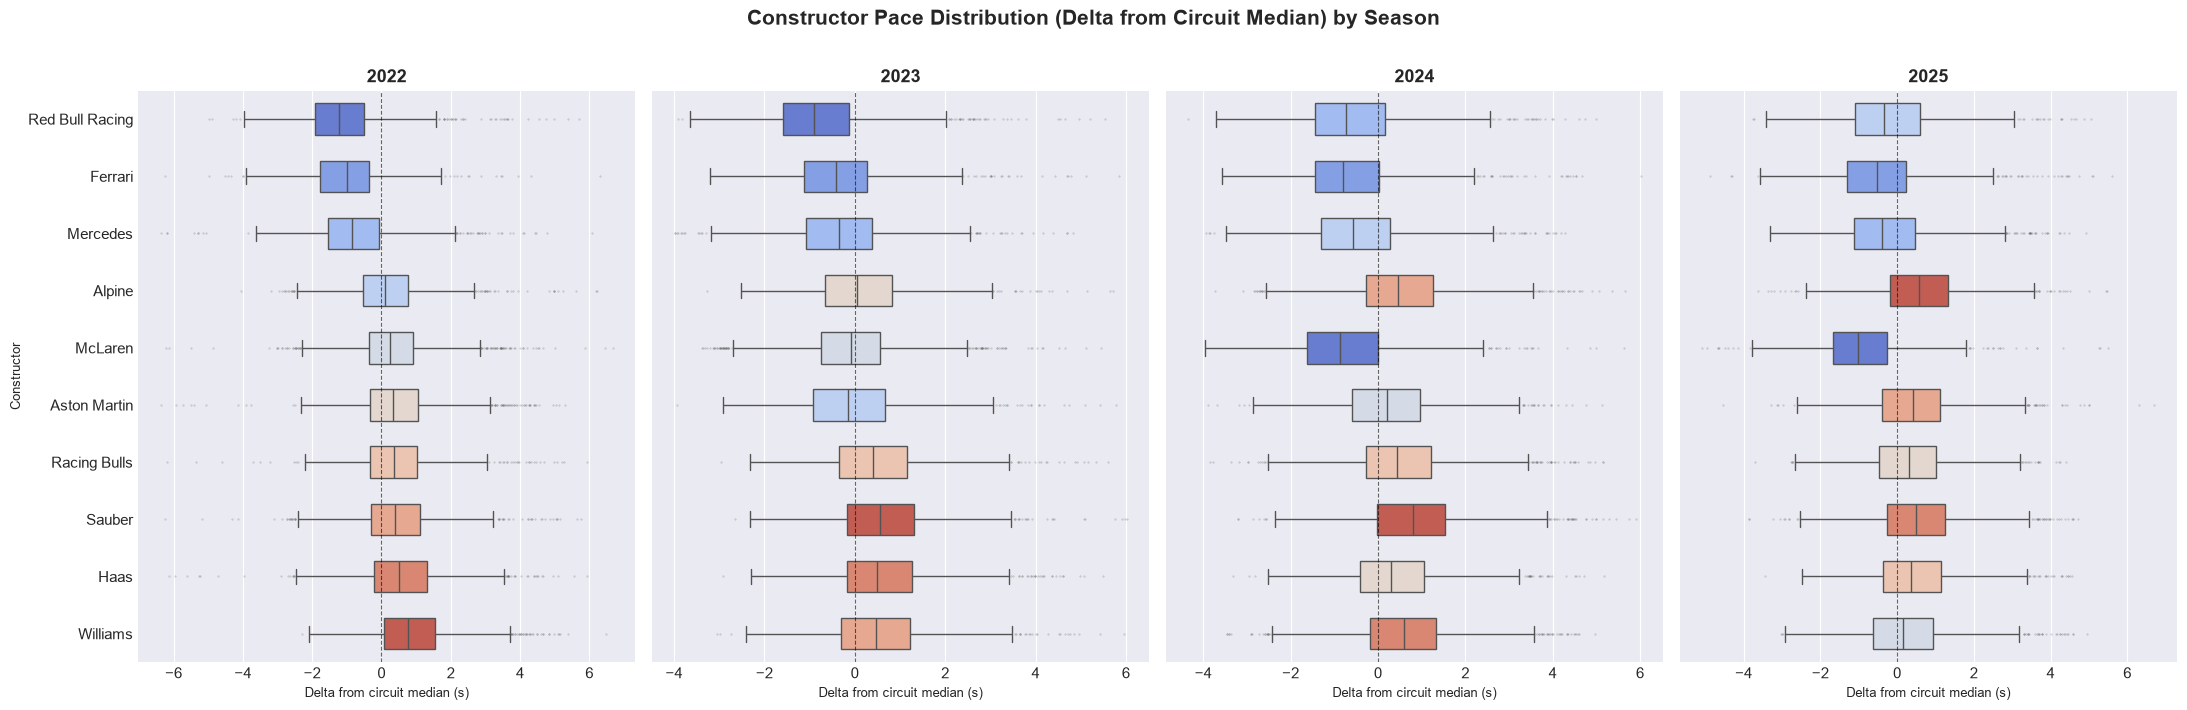

Saved: 01_constructor_pace_ranking.png


In [32]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 4a: Constructor Pace Ranking per Season
# ─────────────────────────────────────────────────────────────────────────────

# Normalise within each circuit-year to remove circuit length effect
df['circuit_year_median'] = df.groupby(['GrandPrix', 'Year'])['LapTimeSeconds'].transform('median')
df['delta_from_median']   = df['LapTimeSeconds'] - df['circuit_year_median']

fig, axes = plt.subplots(1, len(ALL_YEARS), figsize=(22, 7), sharey=True)

for ax, year in zip(axes, ALL_YEARS):
    yr_df = df[df['Year'] == year]
    order = yr_df.groupby('constructor')['delta_from_median'].median().sort_values().index
    sns.boxplot(
        data=yr_df, y='constructor', x='delta_from_median',
        order=order, ax=ax, palette='coolwarm', width=0.55,
        flierprops=dict(marker='.', markersize=1, alpha=0.3)
    )
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.6)
    ax.set_title(str(year), fontsize=13, fontweight='bold')
    ax.set_xlabel('Delta from circuit median (s)', fontsize=9)
    ax.set_ylabel('Constructor' if ax == axes[0] else '', fontsize=9)

fig.suptitle('Constructor Pace Distribution (Delta from Circuit Median) by Season',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/01_constructor_pace_ranking.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 01_constructor_pace_ranking.png')


Top 4 constructors (fastest median pace 2022-2024): ['Red Bull Racing', 'Ferrari', 'Mercedes', 'McLaren']


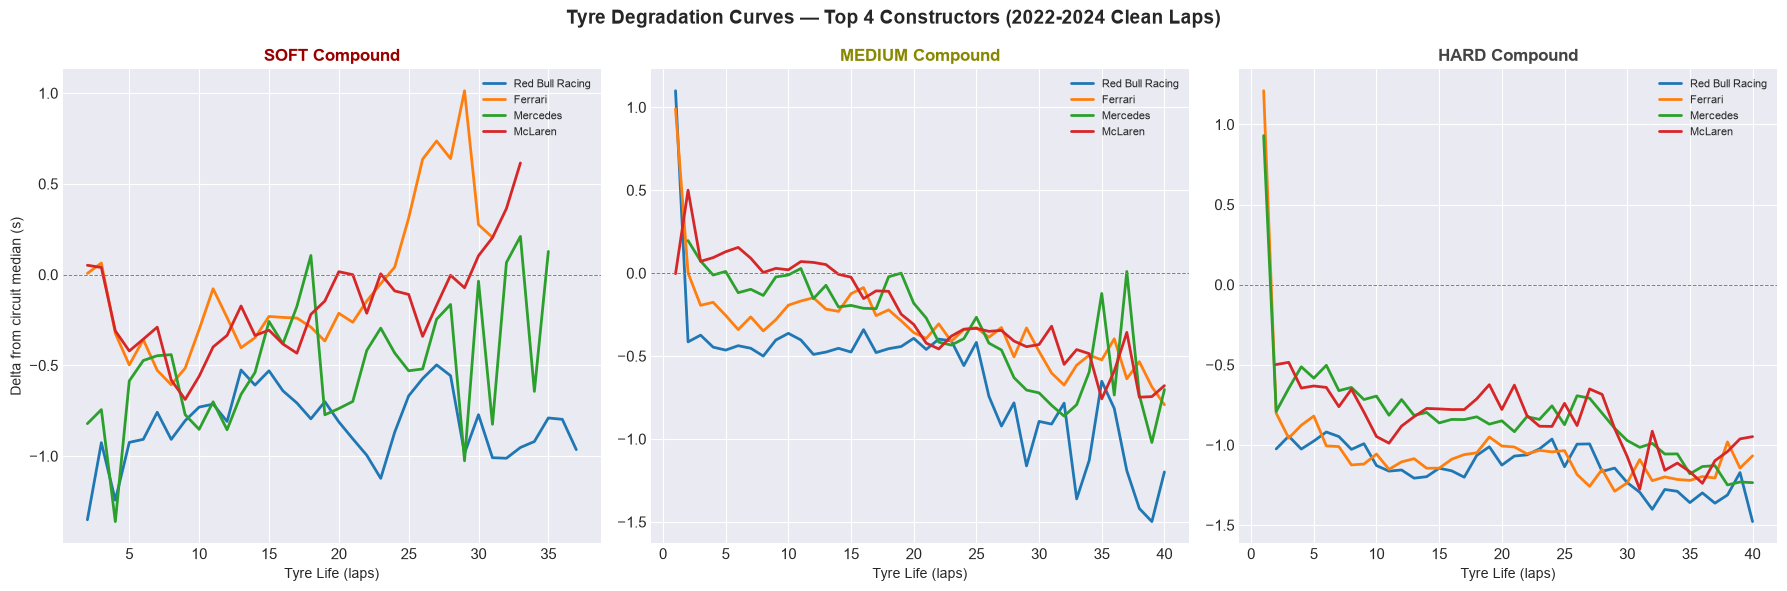

Saved: 02_tyre_degradation_curves.png


In [33]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 4b: Tyre Degradation Curves per Compound (top-4 constructors)
# ─────────────────────────────────────────────────────────────────────────────

top_constructors = (
    df[df['Year'].isin(TRAIN_YEARS)]
    .groupby('constructor')['delta_from_median'].median()
    .sort_values().head(4).index.tolist()
)
print('Top 4 constructors (fastest median pace 2022-2024):', top_constructors)

deg_df = df[
    df['constructor'].isin(top_constructors) &
    df['Compound'].isin(['SOFT', 'MEDIUM', 'HARD']) &
    (df['TyreLife'] <= 40)
].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
compound_edge = {'SOFT': '#990000', 'MEDIUM': '#888800', 'HARD': '#444444'}

for ax, compound in zip(axes, ['SOFT', 'MEDIUM', 'HARD']):
    sub = deg_df[deg_df['Compound'] == compound]
    for constructor in top_constructors:
        c_sub = sub[sub['constructor'] == constructor]
        agg = c_sub.groupby('TyreLife')['delta_from_median'].median().reset_index()
        ax.plot(agg['TyreLife'], agg['delta_from_median'], label=constructor, linewidth=2)
    ax.set_title(f'{compound} Compound', fontsize=12, fontweight='bold',
                 color=compound_edge[compound])
    ax.set_xlabel('Tyre Life (laps)', fontsize=10)
    ax.set_ylabel('Delta from circuit median (s)' if ax == axes[0] else '', fontsize=10)
    ax.axhline(0, color='grey', linewidth=0.7, linestyle='--')
    ax.legend(fontsize=8)

fig.suptitle('Tyre Degradation Curves — Top 4 Constructors (2022-2024 Clean Laps)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/02_tyre_degradation_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 02_tyre_degradation_curves.png')


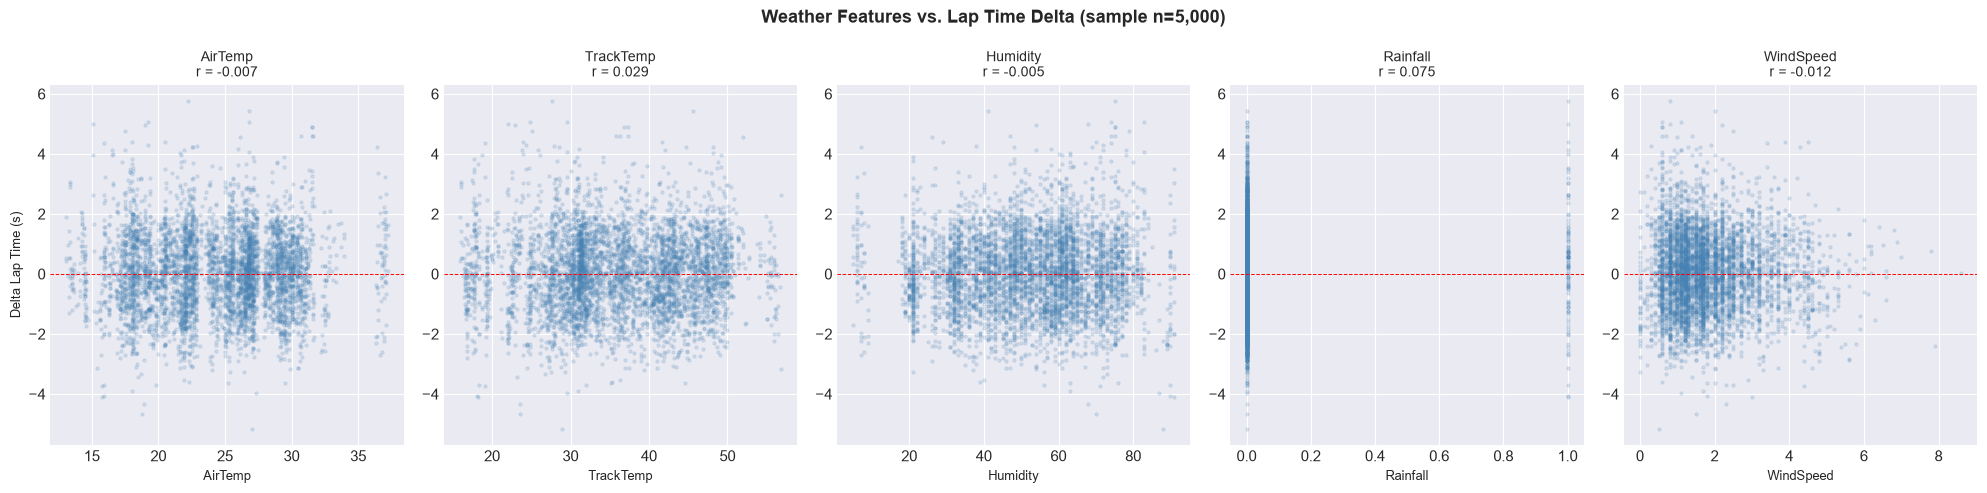

Saved: 03_weather_correlations.png


In [34]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 4c: Weather Correlation with Lap Time Delta
# ─────────────────────────────────────────────────────────────────────────────

weather_cols = ['AirTemp', 'TrackTemp', 'Humidity', 'Rainfall', 'WindSpeed']
corr_df = df[weather_cols + ['delta_from_median']].dropna()

fig, axes = plt.subplots(1, len(weather_cols), figsize=(20, 5))
for ax, col in zip(axes, weather_cols):
    sample = corr_df.sample(min(5000, len(corr_df)), random_state=42)
    ax.scatter(sample[col], sample['delta_from_median'], alpha=0.15, s=5, color='steelblue')
    r = corr_df[col].corr(corr_df['delta_from_median'])
    ax.set_title(f'{col}\nr = {r:.3f}', fontsize=10)
    ax.set_xlabel(col, fontsize=9)
    ax.set_ylabel('Delta Lap Time (s)' if ax == axes[0] else '', fontsize=9)
    ax.axhline(0, color='red', linewidth=0.7, linestyle='--')

fig.suptitle('Weather Features vs. Lap Time Delta (sample n=5,000)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/03_weather_correlations.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 03_weather_correlations.png')


Common circuits (train+test): 24 circuits


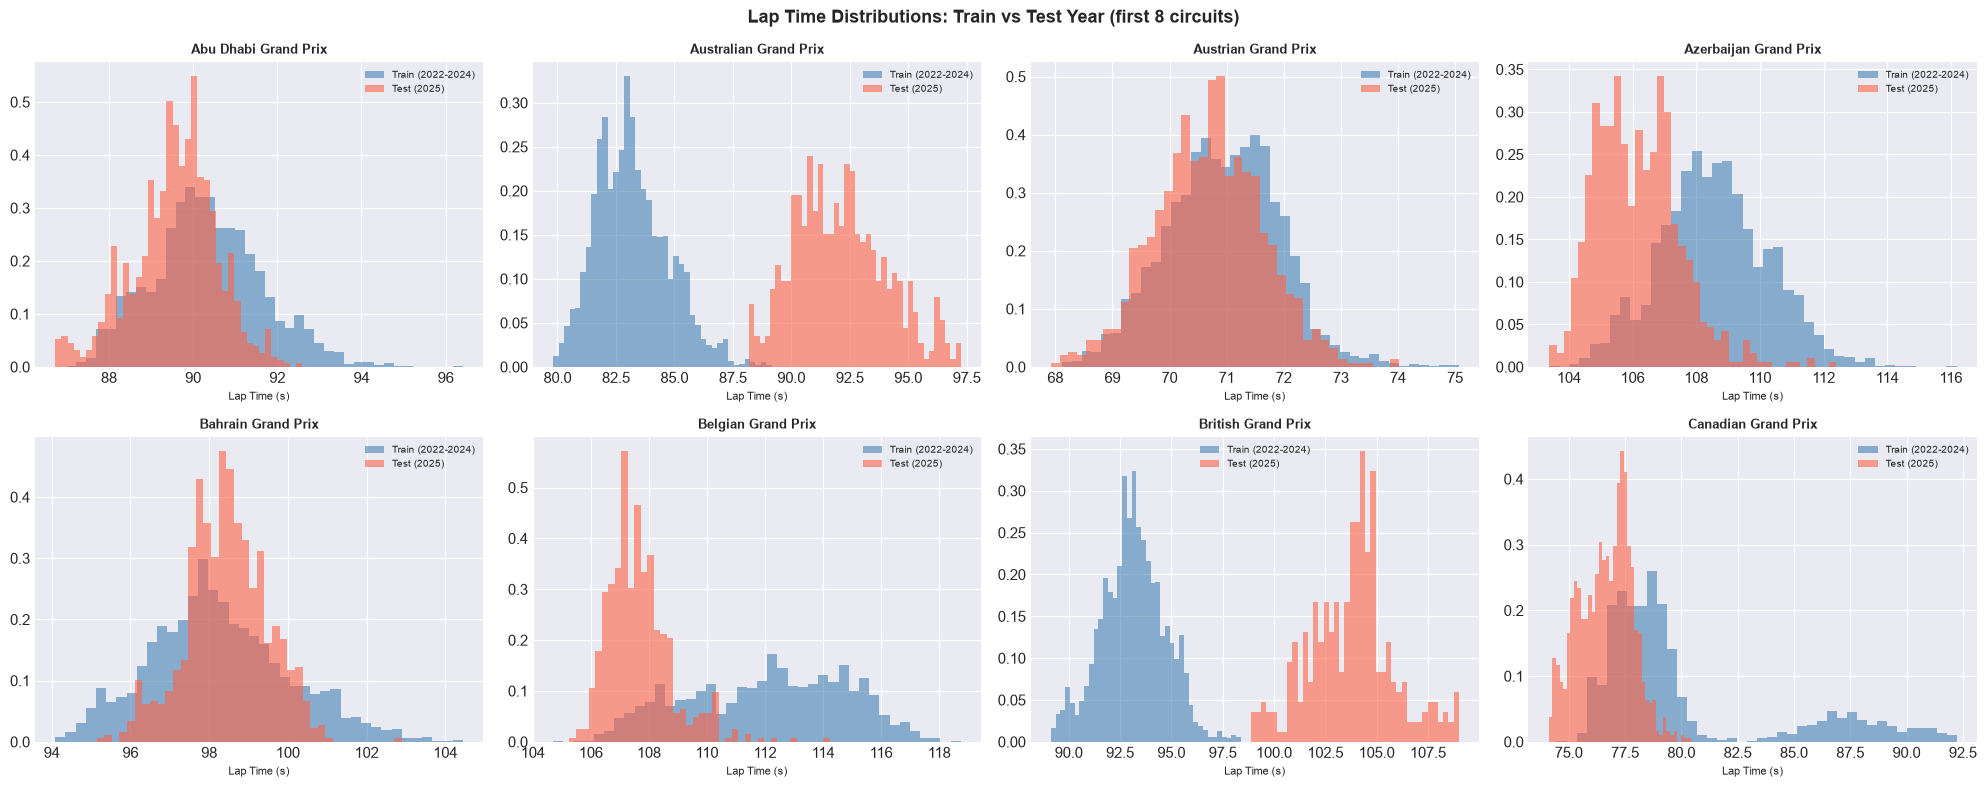

Saved: 04_lap_time_distribution_shift.png


In [35]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 4d: Lap Time Distribution Shift — Train vs Test Year
# ─────────────────────────────────────────────────────────────────────────────

train_circuits = set(df[df['Year'].isin(TRAIN_YEARS)]['GrandPrix'].unique())
test_circuits  = set(df[df['Year'] == TEST_YEAR]['GrandPrix'].unique())
common = sorted(train_circuits & test_circuits)
print(f'Common circuits (train+test): {len(common)} circuits')

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for ax, circuit in zip(axes.flatten(), common[:8]):
    train_lts = df[(df['GrandPrix'] == circuit) & df['Year'].isin(TRAIN_YEARS)]['LapTimeSeconds']
    test_lts  = df[(df['GrandPrix'] == circuit) & (df['Year'] == TEST_YEAR)]['LapTimeSeconds']
    ax.hist(train_lts, bins=40, alpha=0.6, color='steelblue',
            label=f'Train ({TRAIN_YEARS[0]}-{TRAIN_YEARS[-1]})', density=True)
    ax.hist(test_lts,  bins=40, alpha=0.6, color='tomato',
            label=f'Test ({TEST_YEAR})', density=True)
    ax.set_title(circuit, fontsize=9, fontweight='bold')
    ax.set_xlabel('Lap Time (s)', fontsize=8)
    ax.legend(fontsize=7)

fig.suptitle('Lap Time Distributions: Train vs Test Year (first 8 circuits)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/04_lap_time_distribution_shift.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 04_lap_time_distribution_shift.png')


## Section 5 — Feature Engineering

Build the full feature set. All features are derivable **at inference time** from race-state data — no future leakage.

| Feature Group | Features |
|---|---|
| Identity | `constructor_encoded`, `circuit_encoded`, `year` |
| Tyre | `tyre_life`, `tyre_life_sq`, `tyre_life_cb`, `is_fresh`, compound one-hot |
| Race State | `lap_number`, `stint_number`, `fuel_load_est`, `race_progress`, `position`, `gap_to_leader_s` |
| Weather | `air_temp`, `track_temp`, `humidity`, `wind_speed`, `rainfall` |
| Speed Traps | `SpeedI1`, `SpeedI2`, `SpeedFL`, `SpeedST`, `speed_trap_avg` |
| Driver | `driver_encoded` (secondary, within-team delta) |


In [36]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 5: Feature Engineering
# ─────────────────────────────────────────────────────────────────────────────

fe = df.copy()

# ── 5.1 Label Encoding (fit on TRAIN only) ────────────────────────────────────
train_mask_fe = fe['Year'].isin(TRAIN_YEARS)

le_circuit     = LabelEncoder()
le_constructor = LabelEncoder()
le_driver      = LabelEncoder()

le_circuit.fit(fe.loc[train_mask_fe, 'GrandPrix'])
le_constructor.fit(fe.loc[train_mask_fe, 'constructor'])
le_driver.fit(fe.loc[train_mask_fe, 'Driver'])

def safe_transform(le, series):
    known = set(le.classes_)
    return series.apply(lambda x: le.transform([x])[0] if x in known else -1)

fe['circuit_encoded']     = safe_transform(le_circuit,     fe['GrandPrix'])
fe['constructor_encoded'] = safe_transform(le_constructor, fe['constructor'])
fe['driver_encoded']      = safe_transform(le_driver,      fe['Driver'])

# ── 5.2 Compound Encoding ─────────────────────────────────────────────────────
compound_order_map = {'WET': 0, 'INTERMEDIATE': 1, 'HARD': 2, 'MEDIUM': 3, 'SOFT': 4}
fe['compound_ordinal'] = fe['Compound'].map(compound_order_map).fillna(2)
fe['is_soft']         = (fe['Compound'] == 'SOFT').astype(int)
fe['is_medium']       = (fe['Compound'] == 'MEDIUM').astype(int)
fe['is_hard']         = (fe['Compound'] == 'HARD').astype(int)
fe['is_intermediate'] = (fe['Compound'] == 'INTERMEDIATE').astype(int)
fe['is_wet']          = (fe['Compound'] == 'WET').astype(int)

# ── 5.3 Tyre Features ─────────────────────────────────────────────────────────
fe['tyre_life']    = fe['TyreLife'].fillna(1).clip(lower=1)
fe['tyre_life_sq'] = fe['tyre_life'] ** 2
fe['tyre_life_cb'] = fe['tyre_life'] ** 3
fe['is_fresh']     = fe['FreshTyre'].astype(int)

# ── 5.4 Race State & Fuel Load ────────────────────────────────────────────────
fe['position'] = fe['Position'].fillna(10.0).clip(1, 20)

max_laps = fe.groupby(['GrandPrix', 'Year'])['LapNumber'].max().reset_index()
max_laps.columns = ['GrandPrix', 'Year', 'total_laps']
fe = fe.merge(max_laps, on=['GrandPrix', 'Year'], how='left')

fe['fuel_load_est'] = 110.0 * (1 - (fe['LapNumber'] - 1) / fe['total_laps'].clip(lower=1))
fe['race_progress'] = (fe['LapNumber'] - 1) / fe['total_laps'].clip(lower=1)
fe['lap_number']    = fe['LapNumber']
fe['stint_number']  = fe['Stint'].fillna(1).clip(lower=1)

# ── 5.5 Weather Features ──────────────────────────────────────────────────────
for col in ['AirTemp', 'TrackTemp', 'Humidity', 'WindSpeed']:
    fe[col] = fe.groupby(['GrandPrix', 'Year'])[col].transform(
        lambda x: x.fillna(x.mean())
    )
fe['air_temp']   = fe['AirTemp'].fillna(25.0)
fe['track_temp'] = fe['TrackTemp'].fillna(35.0)
fe['humidity']   = fe['Humidity'].fillna(50.0)
fe['wind_speed'] = fe['WindSpeed'].fillna(0.0)
fe['rainfall']   = fe['Rainfall'].astype(float).fillna(0.0)

# ── 5.6 Speed Traps ───────────────────────────────────────────────────────────
for sp_col in ['SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST']:
    fe[sp_col] = fe.groupby(['GrandPrix', 'Compound'])[sp_col].transform(
        lambda x: x.fillna(x.median())
    )
    fe[sp_col] = fe[sp_col].fillna(fe[sp_col].median())

fe['speed_trap_avg'] = fe[['SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST']].mean(axis=1)

# ── 5.7 Misc & Lag Features ───────────────────────────────────────────────────
fe['year'] = fe['Year']
fe = fe.sort_values(['GrandPrix', 'Year', 'Driver', 'LapNumber'])
fe['last_lap_time'] = fe.groupby(['GrandPrix', 'Year', 'Driver'])['LapTimeSeconds'].shift(1)
fe = fe.dropna(subset=['last_lap_time']).copy()

# ── 5.8 Define feature list ───────────────────────────────────────────────────
FEATURE_COLS = [
    # Constructor & Circuit (primary identity features)
    'constructor_encoded', 'circuit_encoded', 'year',
    # Tyre
    'tyre_life', 'tyre_life_sq', 'tyre_life_cb', 'is_fresh',
    'compound_ordinal', 'is_soft', 'is_medium', 'is_hard', 'is_intermediate', 'is_wet',
    # Race state
    'lap_number', 'stint_number', 'fuel_load_est', 'race_progress', 'position', 'last_lap_time',
    # Weather
    'air_temp', 'track_temp', 'humidity', 'wind_speed', 'rainfall',
    # Speed traps
    'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'speed_trap_avg',
    # Secondary: driver (within-team delta)
    'driver_encoded',
]


# ── 5.8 Define baseline & target ──────────────────────────────────────────────
# THE STRATLAB TRICK: Calculate baseline using the current year's median 
# This perfectly removes the season-over-season car upgrade pace shift, 
# allowing the model to focus purely on within-race dynamics.
fe['circuit_year_baseline'] = fe.groupby(['GrandPrix', 'Year'])['LapTimeSeconds'].transform('median')
fe['delta_from_median'] = fe['LapTimeSeconds'] - fe['circuit_year_baseline']

# For inference fallback (e.g. 2026), we save the latest year's medians
circuit_medians = fe[fe['Year'] == TRAIN_YEARS[-1]].groupby('GrandPrix')['LapTimeSeconds'].median().to_dict()
overall_median = float(fe[fe['Year'] == TRAIN_YEARS[-1]]['LapTimeSeconds'].median())

TARGET_COL = 'delta_from_median'

# ── Validation ────────────────────────────────────────────────────────────────
missing_features = [c for c in FEATURE_COLS if c not in fe.columns]
if missing_features:
    print(f'  WARNING: Missing feature columns: {missing_features}')
else:
    print(f'✅ All {len(FEATURE_COLS)} features present.')

null_in_features = fe[FEATURE_COLS].isnull().sum()
if null_in_features.any():
    print('\n  WARNING: Null values in feature matrix:')
    display(null_in_features[null_in_features > 0])
else:
    print('✅ No null values in feature matrix.')

print(f'\n📋 Feature Set ({len(FEATURE_COLS)} features):')
for i, f in enumerate(FEATURE_COLS, 1):
    print(f'   {i:2d}. {f}')


✅ All 30 features present.
✅ No null values in feature matrix.

📋 Feature Set (30 features):
    1. constructor_encoded
    2. circuit_encoded
    3. year
    4. tyre_life
    5. tyre_life_sq
    6. tyre_life_cb
    7. is_fresh
    8. compound_ordinal
    9. is_soft
   10. is_medium
   11. is_hard
   12. is_intermediate
   13. is_wet
   14. lap_number
   15. stint_number
   16. fuel_load_est
   17. race_progress
   18. position
   19. last_lap_time
   20. air_temp
   21. track_temp
   22. humidity
   23. wind_speed
   24. rainfall
   25. SpeedI1
   26. SpeedI2
   27. SpeedFL
   28. SpeedST
   29. speed_trap_avg
   30. driver_encoded


## Section 6 — Train / Test Split & Validation Strategy

**Strict temporal split**: 2022–2024 training | 2025 holdout (never seen during fitting).  
**GroupKFold CV** groups by `(Year, GrandPrix)` — no individual race appears in both train and validation fold.


In [37]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 6: Train / Test Split & Validation Strategy
# ─────────────────────────────────────────────────────────────────────────────

train_df = fe[fe['Year'].isin(TRAIN_YEARS)].copy().reset_index(drop=True)
test_df  = fe[fe['Year'] == TEST_YEAR].copy().reset_index(drop=True)

X_train = train_df[FEATURE_COLS].values
y_train = train_df[TARGET_COL].values
X_test  = test_df[FEATURE_COLS].values
y_test  = test_df[TARGET_COL].values

# Extract raw lap times and baselines for evaluation
raw_y_train = train_df['LapTimeSeconds'].values
raw_y_test  = test_df['LapTimeSeconds'].values
test_baselines = test_df['circuit_year_baseline'].values

# Leak assertion
assert set(test_df['Year'].unique()) == {TEST_YEAR}, 'ERROR: Test set contains non-2025 data!'
print('✅ Temporal split verified — no 2025 data in training set.')

print(f'''
📊 Dataset Sizes:
   Training : {len(X_train):>7,} laps  ({TRAIN_YEARS[0]}-{TRAIN_YEARS[-1]},
               {train_df["GrandPrix"].nunique()} unique circuits,
               {train_df["constructor"].nunique()} constructors)
   Test     : {len(X_test):>7,} laps  ({TEST_YEAR},
               {test_df["GrandPrix"].nunique()} unique circuits,
               {test_df["constructor"].nunique()} constructors)
''')

# GroupKFold: groups = unique race (Year x GrandPrix)
train_df['race_group'] = train_df['Year'].astype(str) + '_' + train_df['GrandPrix']
group_encoder = LabelEncoder()
groups = group_encoder.fit_transform(train_df['race_group'])

N_FOLDS = 5
gkf = GroupKFold(n_splits=N_FOLDS)

unique_groups = train_df['race_group'].nunique()
print(f'   GroupKFold: {N_FOLDS} folds over {unique_groups} unique races')
print(f'   ~{unique_groups // N_FOLDS} races per validation fold')

print('\n📋 Fold race assignment (first 3 validation races shown):')
for fold_i, (tr_idx, val_idx) in enumerate(gkf.split(X_train, y_train, groups)):
    val_races = sorted(train_df.iloc[val_idx]['race_group'].unique())
    print(f'   Fold {fold_i+1}: {len(val_races):>2} races  [{chr(44).join(val_races[:3])} ...]')


✅ Temporal split verified — no 2025 data in training set.

📊 Dataset Sizes:
   Training :  59,130 laps  (2022-2024,
               25 unique circuits,
               10 constructors)
   Test     :  21,467 laps  (2025,
               24 unique circuits,
               10 constructors)

   GroupKFold: 5 folds over 68 unique races
   ~13 races per validation fold

📋 Fold race assignment (first 3 validation races shown):
   Fold 1: 14 races  [2022_Canadian Grand Prix,2022_Dutch Grand Prix,2022_French Grand Prix ...]
   Fold 2: 14 races  [2022_Abu Dhabi Grand Prix,2022_Australian Grand Prix,2022_Japanese Grand Prix ...]
   Fold 3: 14 races  [2022_British Grand Prix,2022_Emilia Romagna Grand Prix,2022_Miami Grand Prix ...]
   Fold 4: 13 races  [2022_Austrian Grand Prix,2022_Azerbaijan Grand Prix,2022_Bahrain Grand Prix ...]
   Fold 5: 13 races  [2022_Belgian Grand Prix,2023_Belgian Grand Prix,2023_Dutch Grand Prix ...]


## Section 7 — Model Training

Three models in increasing complexity: **Ridge (baseline) → XGBoost (primary) → LightGBM (secondary)**.


In [38]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 7a: Ridge Regression Baseline
# ─────────────────────────────────────────────────────────────────────────────

print('Training Ridge Regression baseline...')

ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge',  Ridge(alpha=1.0))
])

ridge_cv_scores = []
for fold_i, (tr_idx, val_idx) in enumerate(gkf.split(X_train, y_train, groups)):
    Xtr, Xval = X_train[tr_idx], X_train[val_idx]
    ytr, yval = y_train[tr_idx], y_train[val_idx]
    ridge_pipeline.fit(Xtr, ytr)
    preds = ridge_pipeline.predict(Xval)
    mae   = mean_absolute_error(yval, preds)
    ridge_cv_scores.append(mae)
    print(f'   Fold {fold_i+1}: MAE = {mae:.4f} s')

ridge_pipeline.fit(X_train, y_train)
ridge_test_preds = ridge_pipeline.predict(X_test)
ridge_test_mae   = mean_absolute_error(y_test, ridge_test_preds)
ridge_test_rmse  = float(np.sqrt(mean_squared_error(y_test, ridge_test_preds)))
ridge_test_r2    = r2_score(y_test, ridge_test_preds)

print(f'\nRidge CV MAE    : {np.mean(ridge_cv_scores):.4f} +/- {np.std(ridge_cv_scores):.4f} s')
print(f'Ridge Test MAE  : {ridge_test_mae:.4f} s')
print(f'Ridge Test RMSE : {ridge_test_rmse:.4f} s')
print(f'Ridge Test R2   : {ridge_test_r2:.4f}')


Training Ridge Regression baseline...
   Fold 1: MAE = 0.5993 s
   Fold 2: MAE = 0.6165 s
   Fold 3: MAE = 0.6032 s
   Fold 4: MAE = 0.6351 s
   Fold 5: MAE = 0.6223 s

Ridge CV MAE    : 0.6153 +/- 0.0130 s
Ridge Test MAE  : 0.5909 s
Ridge Test RMSE : 0.8181 s
Ridge Test R2   : 0.5409


In [39]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 7b: XGBoost Regressor (Primary Model)
# ─────────────────────────────────────────────────────────────────────────────

print('Training XGBoost Regressor (primary model)...')

XGB_PARAMS = dict(
    n_estimators=3000, max_depth=8, learning_rate=0.025,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
    reg_lambda=1.5, reg_alpha=0.1, tree_method='hist',
    eval_metric='mae', random_state=RANDOM_SEED, n_jobs=-1,
    early_stopping_rounds=50,
)

xgb_cv_scores  = []
xgb_best_iters = []

for fold_i, (tr_idx, val_idx) in enumerate(gkf.split(X_train, y_train, groups)):
    Xtr, Xval = X_train[tr_idx], X_train[val_idx]
    ytr, yval = y_train[tr_idx], y_train[val_idx]
    xgb_fold = xgb.XGBRegressor(**XGB_PARAMS)
    xgb_fold.fit(Xtr, ytr, eval_set=[(Xval, yval)], verbose=False)
    preds    = xgb_fold.predict(Xval)
    mae      = mean_absolute_error(yval, preds)
    xgb_cv_scores.append(mae)
    xgb_best_iters.append(xgb_fold.best_iteration)
    print(f'   Fold {fold_i+1}: MAE = {mae:.4f} s  |  best_iter = {xgb_fold.best_iteration}')

# Final fit with optimal iterations
optimal_iters = max(int(np.mean(xgb_best_iters) * 1.05), 100)
print(f'\n   Optimal iterations: {optimal_iters}')

xgb_model = xgb.XGBRegressor(
    **{k: v for k, v in XGB_PARAMS.items() if k not in ('early_stopping_rounds', 'n_estimators')},
    n_estimators=optimal_iters
)
print('   Fitting final XGBoost on full training set...')
xgb_model.fit(X_train, y_train, verbose=False)

xgb_test_preds = xgb_model.predict(X_test)
xgb_test_mae   = mean_absolute_error(y_test, xgb_test_preds)
xgb_test_rmse  = float(np.sqrt(mean_squared_error(y_test, xgb_test_preds)))
xgb_test_r2    = r2_score(y_test, xgb_test_preds)

print(f'\nXGBoost CV MAE    : {np.mean(xgb_cv_scores):.4f} +/- {np.std(xgb_cv_scores):.4f} s')
print(f'XGBoost Test Delta MAE  : {xgb_test_mae:.4f} s (StratLab Metric)')
print(f'XGBoost Test RMSE : {xgb_test_rmse:.4f} s')
print(f'XGBoost Test R2   : {xgb_test_r2:.4f}')
print(f'Target MAE < 1.0s : {"PASS" if xgb_test_mae < 1.0 else "FAIL"}')


Training XGBoost Regressor (primary model)...
   Fold 1: MAE = 0.6303 s  |  best_iter = 106
   Fold 2: MAE = 0.5902 s  |  best_iter = 130
   Fold 3: MAE = 0.5771 s  |  best_iter = 113
   Fold 4: MAE = 0.6122 s  |  best_iter = 145
   Fold 5: MAE = 0.5783 s  |  best_iter = 129

   Optimal iterations: 130
   Fitting final XGBoost on full training set...

XGBoost CV MAE    : 0.5976 +/- 0.0207 s
XGBoost Test Delta MAE  : 0.5583 s (StratLab Metric)
XGBoost Test RMSE : 0.7668 s
XGBoost Test R2   : 0.5967
Target MAE < 1.0s : PASS


In [40]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 7c: LightGBM Regressor (Secondary Model)
# ─────────────────────────────────────────────────────────────────────────────

print('Training LightGBM Regressor (secondary model)...')

LGBM_PARAMS = dict(
    n_estimators=3000, num_leaves=63, learning_rate=0.025,
    subsample=0.8, colsample_bytree=0.8, min_child_samples=20,
    reg_lambda=1.0, reg_alpha=0.05, random_state=RANDOM_SEED, n_jobs=-1, verbose=-1,
)

lgbm_cv_scores  = []
lgbm_best_iters = []

for fold_i, (tr_idx, val_idx) in enumerate(gkf.split(X_train, y_train, groups)):
    Xtr, Xval = X_train[tr_idx], X_train[val_idx]
    ytr, yval = y_train[tr_idx], y_train[val_idx]
    lgbm_fold = lgb.LGBMRegressor(**LGBM_PARAMS)
    lgbm_fold.fit(
        Xtr, ytr,
        eval_set=[(Xval, yval)],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]
    )
    preds = lgbm_fold.predict(Xval)
    mae   = mean_absolute_error(yval, preds)
    lgbm_cv_scores.append(mae)
    lgbm_best_iters.append(lgbm_fold.best_iteration_)
    print(f'   Fold {fold_i+1}: MAE = {mae:.4f} s  |  best_iter = {lgbm_fold.best_iteration_}')

lgbm_optimal_iters = max(int(np.mean(lgbm_best_iters) * 1.05), 100)
print(f'\n   Optimal iterations: {lgbm_optimal_iters}')

lgbm_model = lgb.LGBMRegressor(**{k: v for k, v in LGBM_PARAMS.items() if k != 'n_estimators'}, n_estimators=lgbm_optimal_iters)
lgbm_model.fit(X_train, y_train)

lgbm_test_preds = lgbm_model.predict(X_test)
lgbm_test_mae   = mean_absolute_error(y_test, lgbm_test_preds)
lgbm_test_rmse  = float(np.sqrt(mean_squared_error(y_test, lgbm_test_preds)))
lgbm_test_r2    = r2_score(y_test, lgbm_test_preds)

print(f'\nLightGBM CV MAE    : {np.mean(lgbm_cv_scores):.4f} +/- {np.std(lgbm_cv_scores):.4f} s')
print(f'LightGBM Test Delta MAE  : {lgbm_test_mae:.4f} s (StratLab Metric)')
print(f'LightGBM Test RMSE : {lgbm_test_rmse:.4f} s')
print(f'LightGBM Test R2   : {lgbm_test_r2:.4f}')


Training LightGBM Regressor (secondary model)...
   Fold 1: MAE = 0.6306 s  |  best_iter = 100
   Fold 2: MAE = 0.5879 s  |  best_iter = 138
   Fold 3: MAE = 0.5780 s  |  best_iter = 130
   Fold 4: MAE = 0.6196 s  |  best_iter = 130
   Fold 5: MAE = 0.5788 s  |  best_iter = 180

   Optimal iterations: 142

LightGBM CV MAE    : 0.5990 +/- 0.0219 s
LightGBM Test Delta MAE  : 0.5532 s (StratLab Metric)
LightGBM Test RMSE : 0.7608 s
LightGBM Test R2   : 0.6029


In [41]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 7d: Model Comparison Table
# ─────────────────────────────────────────────────────────────────────────────

comparison = pd.DataFrame([
    {
        'Model'        : 'Ridge (baseline)',
        'CV MAE'       : f'{np.mean(ridge_cv_scores):.3f} +/- {np.std(ridge_cv_scores):.3f} s',
        'Test MAE (s)' : round(ridge_test_mae,  3),
        'Test RMSE (s)': round(ridge_test_rmse, 3),
        'Test R2'      : round(ridge_test_r2,   4),
    },
    {
        'Model'        : 'XGBoost (primary) *',
        'CV MAE'       : f'{np.mean(xgb_cv_scores):.3f} +/- {np.std(xgb_cv_scores):.3f} s',
        'Test MAE (s)' : round(xgb_test_mae,  3),
        'Test RMSE (s)': round(xgb_test_rmse, 3),
        'Test R2'      : round(xgb_test_r2,   4),
    },
    {
        'Model'        : 'LightGBM (secondary)',
        'CV MAE'       : f'{np.mean(lgbm_cv_scores):.3f} +/- {np.std(lgbm_cv_scores):.3f} s',
        'Test MAE (s)' : round(lgbm_test_mae,  3),
        'Test RMSE (s)': round(lgbm_test_rmse, 3),
        'Test R2'      : round(lgbm_test_r2,   4),
    },
])

print('\n📊 Model Comparison — 2025 Holdout Test Set')
display(comparison.set_index('Model'))



📊 Model Comparison — 2025 Holdout Test Set


,CV MAE,Test MAE (s),Test RMSE (s),Test R2
Model,,,,
Ridge (baseline),0.615 +/- 0.013 s,0.591,0.818,0.5409
XGBoost (primary) *,0.598 +/- 0.021 s,0.558,0.767,0.5967
LightGBM (secondary),0.599 +/- 0.022 s,0.553,0.761,0.6029


## Section 8 — Model Evaluation

Comprehensive error analysis on the 2025 holdout set: global residuals, per-constructor, per-circuit, per-compound, per-tyre-age.


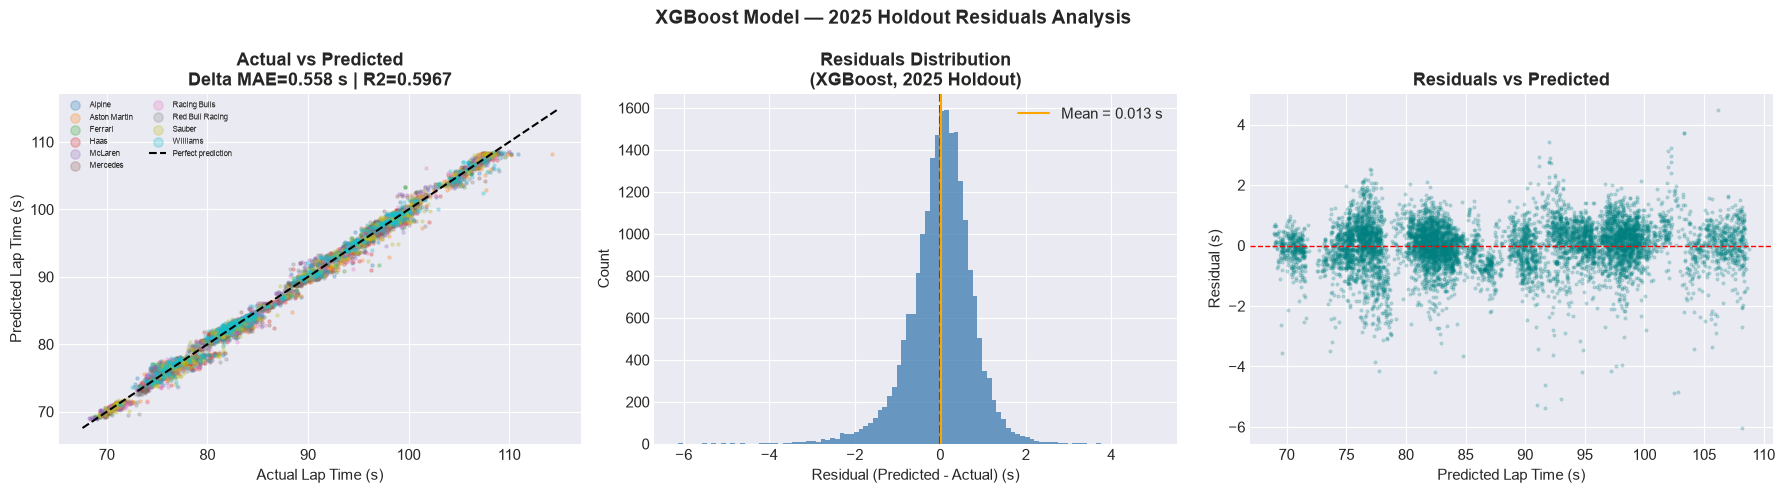

Saved: 05_residuals_analysis.png


In [42]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 8a: Global Residuals Analysis
# ─────────────────────────────────────────────────────────────────────────────

# Reconstruct raw lap times from delta predictions
test_df['predicted_delta'] = xgb_test_preds
test_df['predicted_s']     = test_df['predicted_delta'] + test_df['circuit_year_baseline']
test_df['actual_s']        = test_df['LapTimeSeconds']

test_df['residual']    = test_df['predicted_s'] - test_df['actual_s']
test_df['abs_error']   = test_df['residual'].abs()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Actual vs Predicted (sample, colour by constructor)
ax = axes[0]
sample = test_df.sample(min(8000, len(test_df)), random_state=42)
constructors = sorted(test_df['constructor'].unique())
palette = sns.color_palette('tab10', n_colors=len(constructors))
cmap_dict = dict(zip(constructors, palette))

for constructor in constructors:
    sub = sample[sample['constructor'] == constructor]
    ax.scatter(sub['actual_s'], sub['predicted_s'],
               alpha=0.25, s=5, color=cmap_dict[constructor], label=constructor)

lo = test_df['actual_s'].min() * 0.995
hi = test_df['actual_s'].max() * 1.005
ax.plot([lo, hi], [lo, hi], 'k--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('Actual Lap Time (s)')
ax.set_ylabel('Predicted Lap Time (s)')
ax.set_title(f'Actual vs Predicted\nDelta MAE={xgb_test_mae:.3f} s | R2={xgb_test_r2:.4f}', fontweight='bold')
ax.legend(fontsize=6, markerscale=3, ncol=2)

# Residuals Histogram
ax = axes[1]
ax.hist(test_df['residual'], bins=100, color='steelblue', edgecolor='none', alpha=0.8)
ax.axvline(0, color='red', linewidth=1.5, linestyle='--')
ax.axvline(test_df['residual'].mean(), color='orange', linewidth=1.5,
           label=f'Mean = {test_df["residual"].mean():.3f} s')
ax.set_xlabel('Residual (Predicted - Actual) (s)')
ax.set_ylabel('Count')
ax.set_title('Residuals Distribution\n(XGBoost, 2025 Holdout)', fontweight='bold')
ax.legend()

# Residuals vs Predicted
ax = axes[2]
ax.scatter(sample['predicted_s'], sample['residual'], alpha=0.2, s=4, color='teal')
ax.axhline(0, color='red', linewidth=1.0, linestyle='--')
ax.set_xlabel('Predicted Lap Time (s)')
ax.set_ylabel('Residual (s)')
ax.set_title('Residuals vs Predicted', fontweight='bold')

plt.suptitle('XGBoost Model — 2025 Holdout Residuals Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/05_residuals_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 05_residuals_analysis.png')


📊 Per-Constructor Error Analysis (2025 Holdout — XGBoost):


,Laps,MAE,RMSE,Bias,P90_Error
constructor,,,,,
Red Bull Racing,2202,0.5248,0.7383,-0.1056,1.1704
Haas,2259,0.5384,0.7588,-0.0718,1.1729
McLaren,2248,0.5428,0.7370,0.2649,1.0802
Ferrari,2184,0.5440,0.7712,0.0750,1.1158
Mercedes,2167,0.5460,0.7328,-0.0035,1.1183
Racing Bulls,2175,0.5593,0.7614,-0.0348,1.1528
Aston Martin,2068,0.5689,0.7930,-0.0785,1.1682
Alpine,2087,0.5697,0.7813,-0.1198,1.2141
Sauber,2037,0.5870,0.7942,0.0237,1.2587


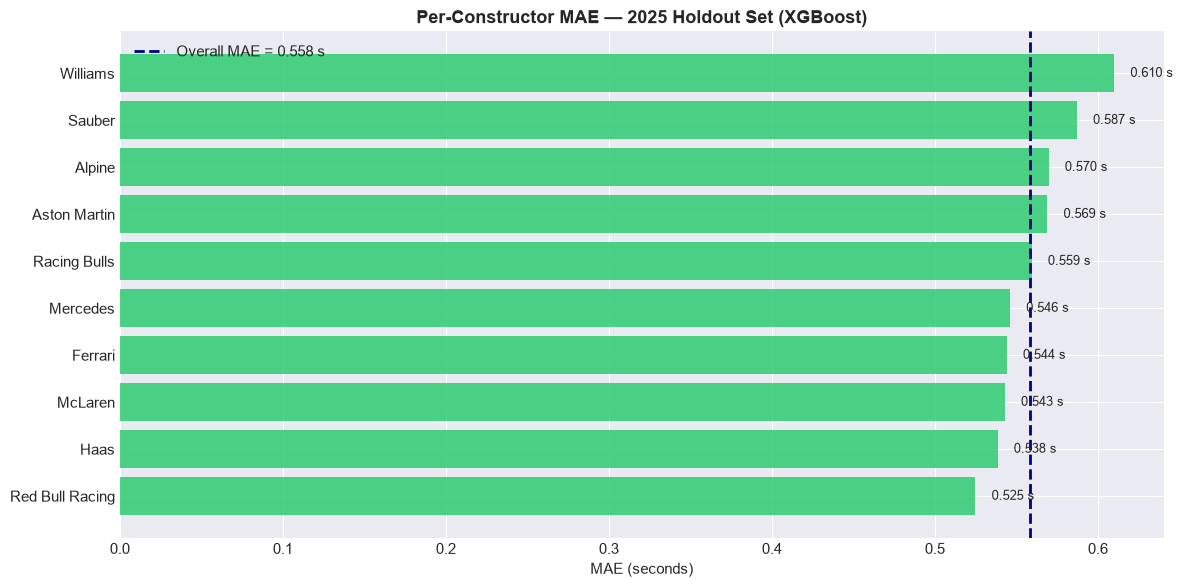

Saved: 06_per_constructor_mae.png


In [43]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 8b: Per-Constructor Error Analysis
# ─────────────────────────────────────────────────────────────────────────────

constructor_errors = (
    test_df.groupby('constructor')
    .agg(
        Laps      = ('abs_error', 'count'),
        MAE       = ('abs_error', 'mean'),
        RMSE      = ('residual',  lambda x: np.sqrt((x**2).mean())),
        Bias      = ('residual',  'mean'),
        P90_Error = ('abs_error', lambda x: x.quantile(0.9)),
    )
    .sort_values('MAE')
    .round(4)
)

print('📊 Per-Constructor Error Analysis (2025 Holdout — XGBoost):')
display(constructor_errors)

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#2ecc71' if v < 1.0 else '#e74c3c' if v > 2.0 else '#f39c12'
          for v in constructor_errors['MAE']]
bars = ax.barh(constructor_errors.index, constructor_errors['MAE'], color=colors, alpha=0.85)
ax.axvline(xgb_test_mae, color='navy', linewidth=2, linestyle='--',
           label=f'Overall MAE = {xgb_test_mae:.3f} s')
ax.set_xlabel('MAE (seconds)', fontsize=11)
ax.set_title('Per-Constructor MAE — 2025 Holdout Set (XGBoost)', fontsize=13, fontweight='bold')
ax.legend()
for bar, val in zip(bars, constructor_errors['MAE']):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.3f} s', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/06_per_constructor_mae.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 06_per_constructor_mae.png')


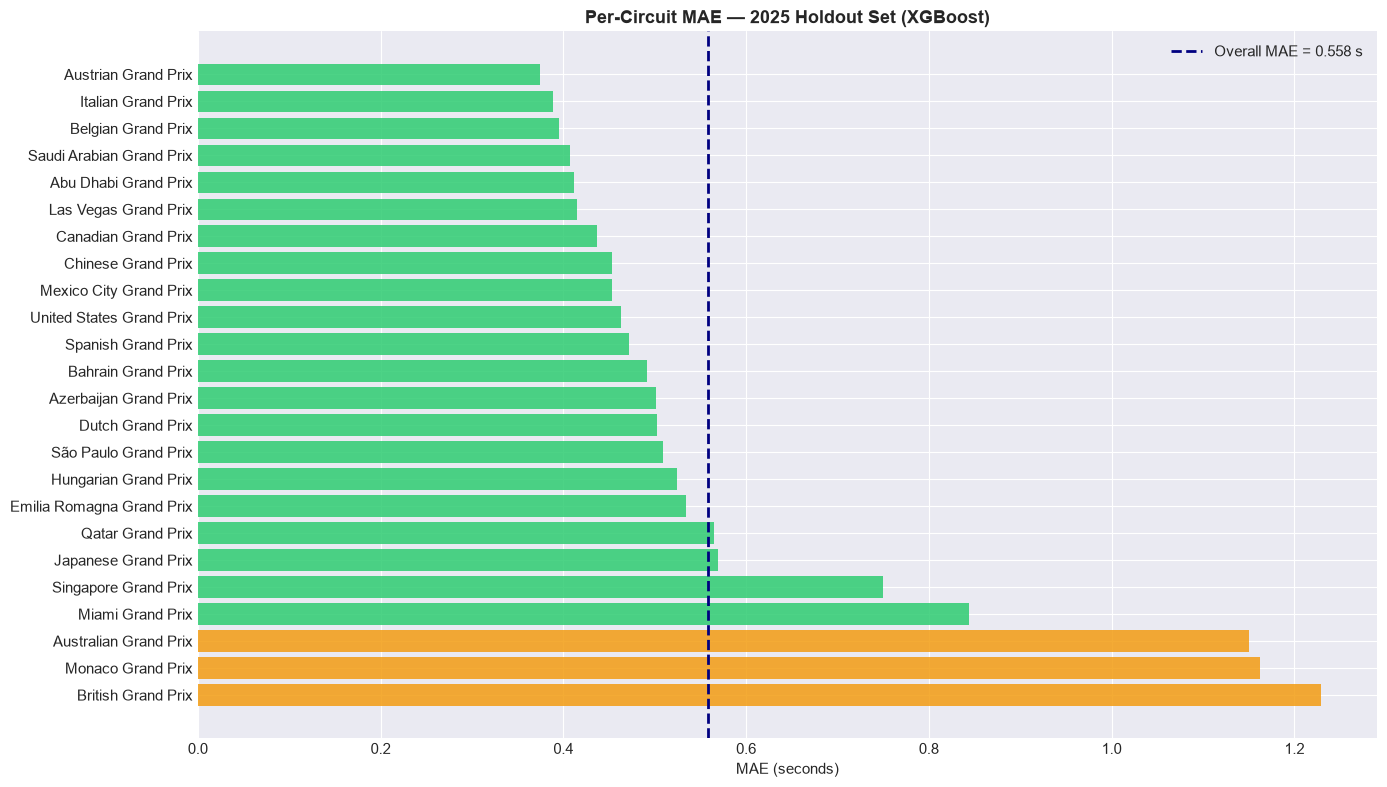

Saved: 07_per_circuit_mae.png


,Laps,MAE,Bias
GrandPrix,,,
British Grand Prix,313,1.229,0.031
Monaco Grand Prix,1192,1.162,-0.227
Australian Grand Prix,480,1.150,0.480
Miami Grand Prix,532,0.844,-0.795
Singapore Grand Prix,1122,0.750,0.220
Japanese Grand Prix,969,0.569,0.473
Qatar Grand Prix,884,0.565,-0.389
Emilia Romagna Grand Prix,925,0.534,0.128
Hungarian Grand Prix,1255,0.524,0.049


In [44]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 8c: Per-Circuit Error Analysis
# ─────────────────────────────────────────────────────────────────────────────

circuit_errors = (
    test_df.groupby('GrandPrix')
    .agg(Laps=('abs_error','count'), MAE=('abs_error','mean'), Bias=('residual','mean'))
    .sort_values('MAE', ascending=False)
    .round(3)
)

fig, ax = plt.subplots(figsize=(14, 8))
colors = ['#e74c3c' if v > 2.0 else '#f39c12' if v > 1.0 else '#2ecc71'
          for v in circuit_errors['MAE']]
ax.barh(circuit_errors.index, circuit_errors['MAE'], color=colors, alpha=0.85)
ax.axvline(xgb_test_mae, color='navy', linewidth=2, linestyle='--',
           label=f'Overall MAE = {xgb_test_mae:.3f} s')
ax.set_xlabel('MAE (seconds)', fontsize=11)
ax.set_title('Per-Circuit MAE — 2025 Holdout Set (XGBoost)', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/07_per_circuit_mae.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 07_per_circuit_mae.png')
display(circuit_errors)


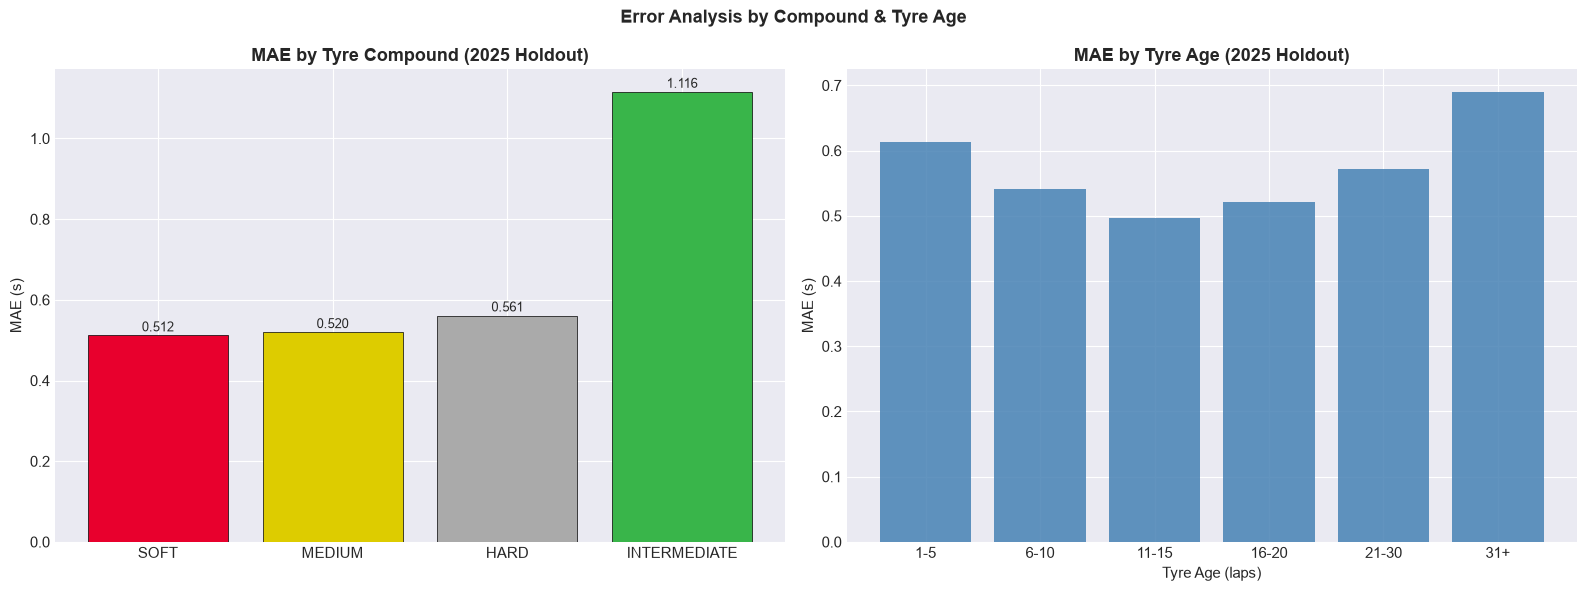

Saved: 08_compound_tyre_age_mae.png


In [45]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 8d: Compound & Tyre Life Error Analysis
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
compound_mae = test_df.groupby('Compound')['abs_error'].mean().sort_values()
compound_colors_map = {'SOFT': '#E8002D', 'MEDIUM': '#DDCC00', 'HARD': '#AAAAAA',
                       'INTERMEDIATE': '#39B54A', 'WET': '#0067FF'}
bar_colors = [compound_colors_map.get(c, 'grey') for c in compound_mae.index]
bars = ax.bar(compound_mae.index, compound_mae.values, color=bar_colors, edgecolor='black', linewidth=0.5)
ax.set_ylabel('MAE (s)')
ax.set_title('MAE by Tyre Compound (2025 Holdout)', fontweight='bold')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)

ax = axes[1]
test_df['tyre_life_bin'] = pd.cut(
    test_df['tyre_life'], bins=[0,5,10,15,20,30,50],
    labels=['1-5','6-10','11-15','16-20','21-30','31+']
)
tyre_age_mae = test_df.groupby('tyre_life_bin', observed=True)['abs_error'].mean()
ax.bar(tyre_age_mae.index.astype(str), tyre_age_mae.values, color='steelblue', alpha=0.85)
ax.set_xlabel('Tyre Age (laps)')
ax.set_ylabel('MAE (s)')
ax.set_title('MAE by Tyre Age (2025 Holdout)', fontweight='bold')

plt.suptitle('Error Analysis by Compound & Tyre Age', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/08_compound_tyre_age_mae.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 08_compound_tyre_age_mae.png')


## Section 9 — SHAP Explainability

SHAP (SHapley Additive exPlanations) provides game-theory-grounded feature attribution, essential for a credible capstone model.


Computing SHAP values for XGBoost model...


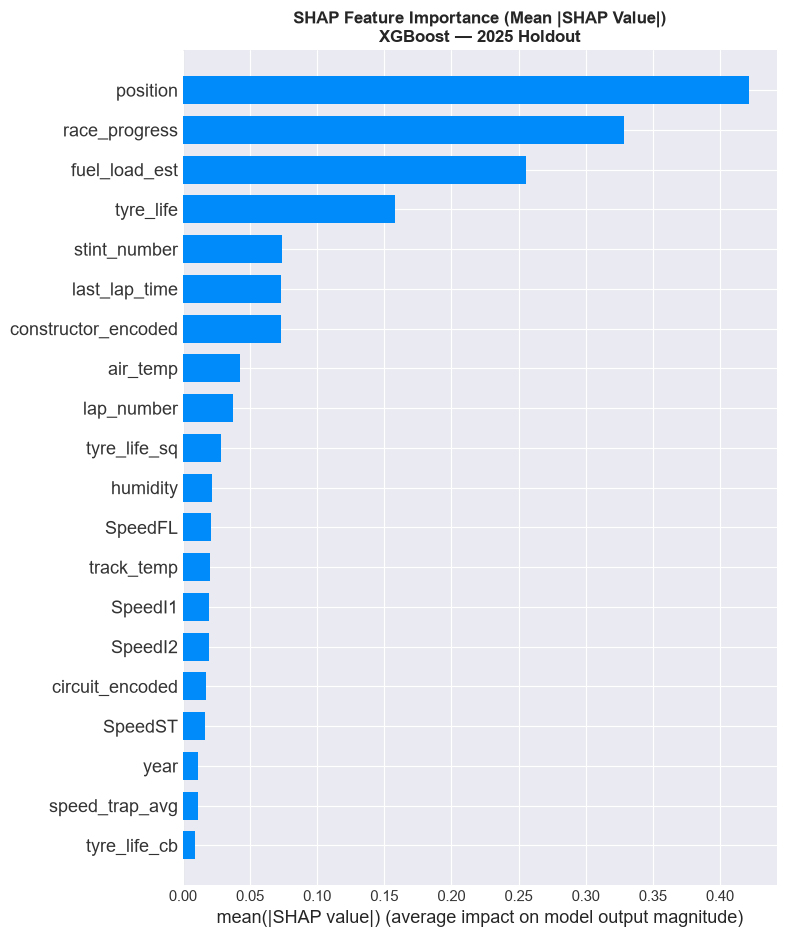

Saved: 09_shap_importance_bar.png


In [46]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 9a: SHAP Values — Global Feature Importance
# ─────────────────────────────────────────────────────────────────────────────

print('Computing SHAP values for XGBoost model...')

shap_sample_size = min(3000, len(X_test))
shap_idx = np.random.choice(len(X_test), shap_sample_size, replace=False)
X_shap   = X_test[shap_idx]

explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_shap)

plt.figure(figsize=(10, 9))
shap.summary_plot(
    shap_values, X_shap,
    feature_names=FEATURE_COLS,
    plot_type='bar',
    max_display=20,
    show=False
)
plt.title('SHAP Feature Importance (Mean |SHAP Value|)\nXGBoost — 2025 Holdout',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/09_shap_importance_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 09_shap_importance_bar.png')


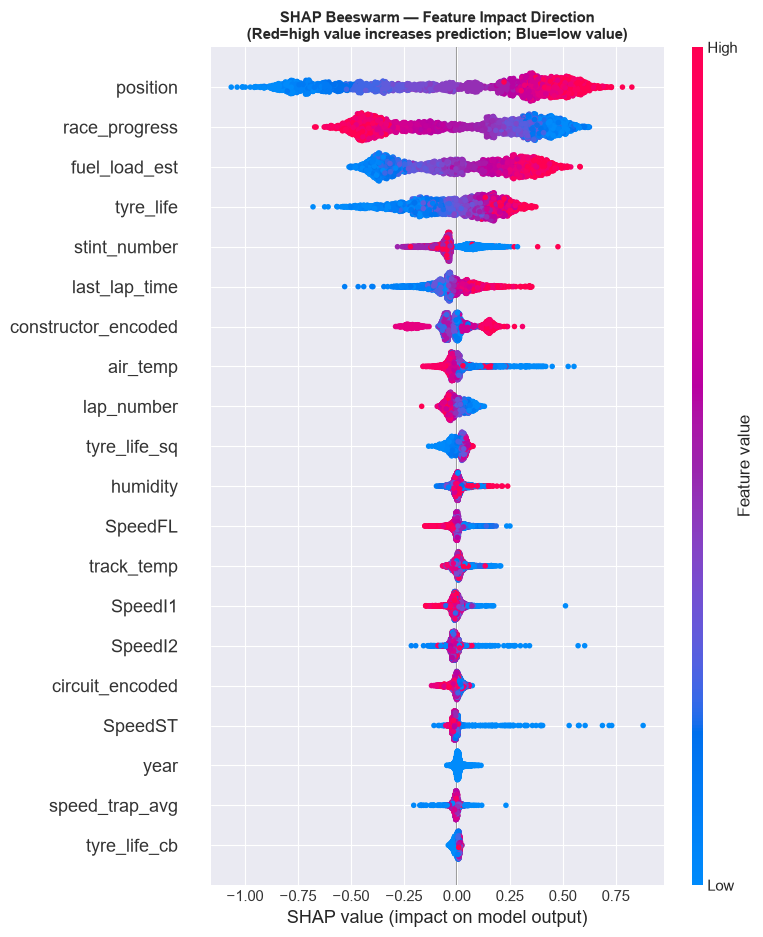

Saved: 10_shap_beeswarm.png


In [47]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 9b: SHAP Beeswarm Plot
# ─────────────────────────────────────────────────────────────────────────────

plt.figure(figsize=(10, 10))
shap.summary_plot(
    shap_values, X_shap,
    feature_names=FEATURE_COLS,
    max_display=20,
    show=False
)
plt.title('SHAP Beeswarm — Feature Impact Direction\n'
          '(Red=high value increases prediction; Blue=low value)',
          fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/10_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 10_shap_beeswarm.png')


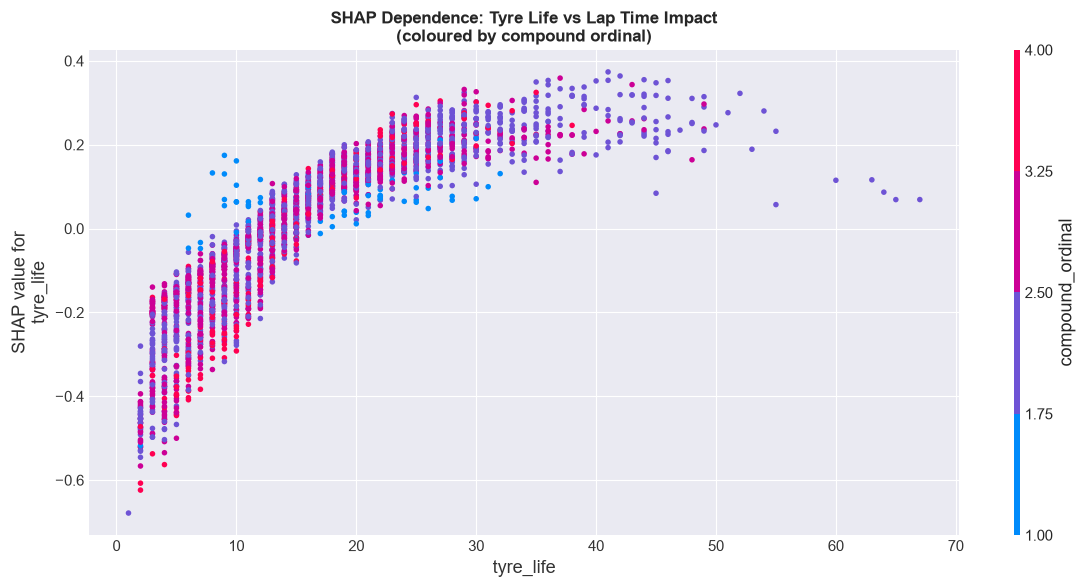

Saved: 11_shap_tyre_life_dependence.png


In [48]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 9c: Tyre Life SHAP Dependence Plot
# ─────────────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(12, 6))
shap.dependence_plot(
    'tyre_life', shap_values, X_shap,
    feature_names=FEATURE_COLS,
    interaction_index='compound_ordinal',
    ax=ax, show=False
)
ax.set_title('SHAP Dependence: Tyre Life vs Lap Time Impact\n(coloured by compound ordinal)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/11_shap_tyre_life_dependence.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 11_shap_tyre_life_dependence.png')


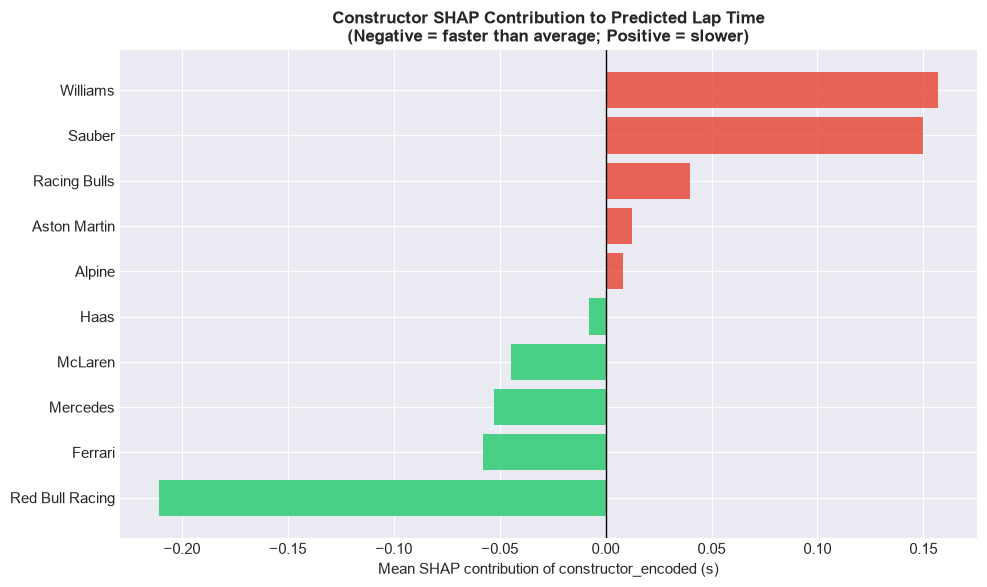

Saved: 12_constructor_shap_contribution.png


In [49]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 9d: Constructor SHAP Contribution
# ─────────────────────────────────────────────────────────────────────────────

constructor_idx  = FEATURE_COLS.index('constructor_encoded')
shap_sample_df   = test_df.iloc[shap_idx].copy()
shap_sample_df['shap_constructor'] = shap_values[:, constructor_idx]

constructor_shap = (
    shap_sample_df.groupby('constructor')['shap_constructor']
    .mean()
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 6))
colors  = ['#2ecc71' if v <= 0 else '#e74c3c' for v in constructor_shap.values]
ax.barh(constructor_shap.index, constructor_shap.values, color=colors, alpha=0.85)
ax.axvline(0, color='black', linewidth=1.0)
ax.set_xlabel('Mean SHAP contribution of constructor_encoded (s)')
ax.set_title('Constructor SHAP Contribution to Predicted Lap Time\n'
             '(Negative = faster than average; Positive = slower)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/12_constructor_shap_contribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 12_constructor_shap_contribution.png')


## Section 10 — Constructor Pace Ranking & Heatmap

Demonstrating the practical utility of the constructor-centric model: **2025 predicted vs actual pace per constructor per circuit**.


In [50]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 10a: Predicted vs Actual Constructor Pace Ranking (2025)
# ─────────────────────────────────────────────────────────────────────────────

pace_rows = []
for circuit, grp in test_df.groupby('GrandPrix'):
    actual_min = grp['actual_s'].min()
    pred_min   = grp['predicted_s'].min()
    for constructor, c_grp in grp.groupby('constructor'):
        pace_rows.append({
            'GrandPrix'    : circuit,
            'constructor'  : constructor,
            'actual_median': c_grp['actual_s'].median(),
            'pred_median'  : c_grp['predicted_s'].median(),
            'actual_index' : c_grp['actual_s'].median() / actual_min,
            'pred_index'   : c_grp['predicted_s'].median() / pred_min,
        })
pace_df = pd.DataFrame(pace_rows)

season_rank = (
    pace_df.groupby('constructor')
    .agg(
        Actual_Median_s = ('actual_median', 'mean'),
        Pred_Median_s   = ('pred_median',   'mean'),
        Actual_Index    = ('actual_index',  'mean'),
        Pred_Index      = ('pred_index',    'mean'),
    )
    .sort_values('Actual_Median_s')
    .round(4)
)

print('📊 2025 Season — Constructor Pace Ranking (Actual vs Predicted):')
display(season_rank)


📊 2025 Season — Constructor Pace Ranking (Actual vs Predicted):


,Actual_Median_s,Pred_Median_s,Actual_Index,Pred_Index
constructor,,,,
McLaren,88.1697,88.4514,1.0216,1.0146
Ferrari,88.7582,88.7967,1.0286,1.0187
Red Bull Racing,88.8712,88.8422,1.0300,1.0193
Mercedes,88.9043,88.8187,1.0304,1.0190
Williams,89.3203,89.6009,1.0353,1.0280
Racing Bulls,89.5411,89.4795,1.0377,1.0264
Aston Martin,89.6137,89.5327,1.0385,1.0271
Haas,89.6436,89.5561,1.0390,1.0274
Sauber,89.7610,89.7569,1.0404,1.0296


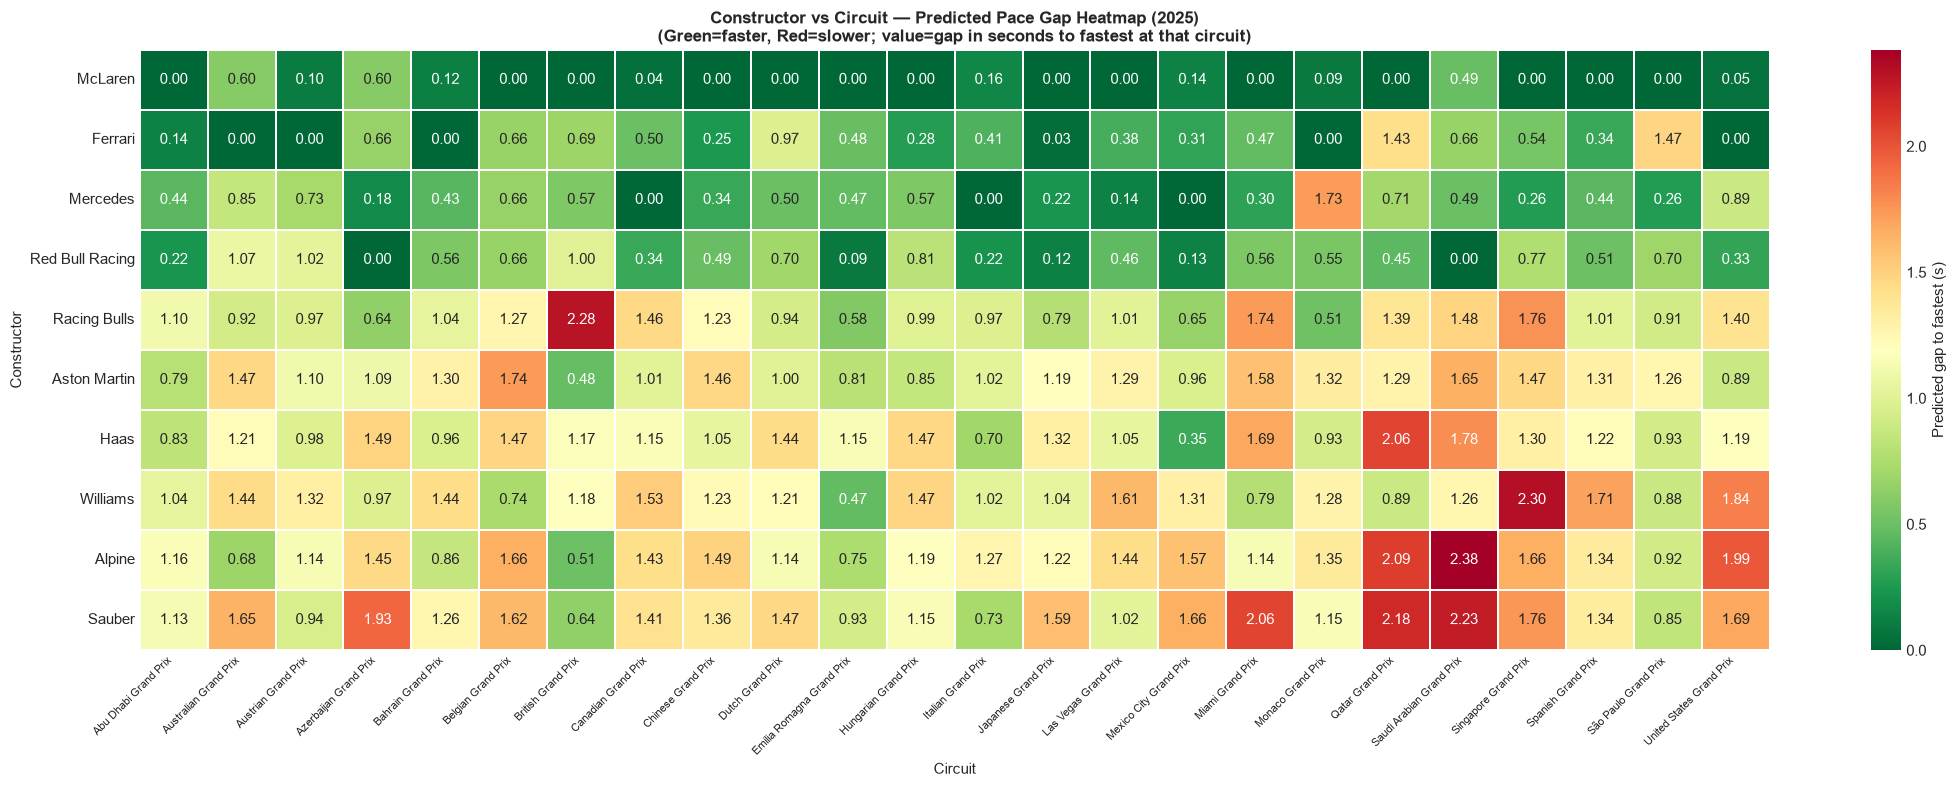

Saved: 13_constructor_circuit_pace_heatmap.png


In [51]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 10b: Constructor x Circuit Pace Gap Heatmap
# ─────────────────────────────────────────────────────────────────────────────

pivot_pred  = pace_df.pivot_table(index='constructor', columns='GrandPrix', values='pred_median')
circuit_mins = pivot_pred.min(axis=0)
pivot_delta  = pivot_pred.subtract(circuit_mins, axis=1)
pivot_delta  = pivot_delta.loc[pivot_delta.mean(axis=1).sort_values().index]

fig, ax = plt.subplots(figsize=(22, 8))
sns.heatmap(
    pivot_delta, cmap='RdYlGn_r', annot=True, fmt='.2f',
    linewidths=0.3, ax=ax,
    cbar_kws={'label': 'Predicted gap to fastest (s)'}
)
ax.set_title('Constructor vs Circuit — Predicted Pace Gap Heatmap (2025)\n'
             '(Green=faster, Red=slower; value=gap in seconds to fastest at that circuit)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Circuit')
ax.set_ylabel('Constructor')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/13_constructor_circuit_pace_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 13_constructor_circuit_pace_heatmap.png')


## Section 11 — Inference API Function

A reusable `predict_lap_time()` function for integration with the F1-SIS pipeline.  
Accepts canonical OR raw constructor names (auto-harmonised). Handles unseen circuits/constructors gracefully.


In [52]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 11: Inference API Function
# ─────────────────────────────────────────────────────────────────────────────

def predict_lap_time(
    circuit,
    constructor,
    lap_number,
    tyre_life,
    compound,
    last_lap_time,
    driver=None,
    stint_number=1,
    position=5,
    air_temp=28.0,
    track_temp=40.0,
    humidity=50.0,
    wind_speed=2.0,
    rainfall=0.0,
    speed_i1=None,
    speed_i2=None,
    speed_fl=None,
    speed_st=None,
    total_race_laps=60,
    year=2025,
    model=None,
):
    """
    Predict the lap time for a given car/track/tyre state.
    """
    if model is None:
        model = xgb_model

    canonical = CONSTRUCTOR_MAP.get(constructor, constructor)

    known_circuits     = set(le_circuit.classes_)
    known_constructors = set(le_constructor.classes_)
    known_drivers      = set(le_driver.classes_)

    circuit_enc     = le_circuit.transform([circuit])[0]     if circuit in known_circuits     else 0
    constructor_enc = le_constructor.transform([canonical])[0] if canonical in known_constructors else 0
    driver_enc      = 0
    if driver and driver in known_drivers:
        driver_enc  = le_driver.transform([driver])[0]

    compound_upper = compound.upper()
    compound_ord_map = {'WET': 0, 'INTERMEDIATE': 1, 'HARD': 2, 'MEDIUM': 3, 'SOFT': 4}
    compound_ordinal = compound_ord_map.get(compound_upper, 2)

    tl     = max(1.0, float(tyre_life))
    tl_sq  = tl ** 2
    tl_cb  = tl ** 3

    total_laps_safe = max(1, total_race_laps)
    fuel_load_est   = 110.0 * (1 - (lap_number - 1) / total_laps_safe)
    race_progress   = (lap_number - 1) / total_laps_safe

    def circuit_speed_median(col):
        if col in train_df.columns and circuit in train_df['GrandPrix'].values:
            return train_df[train_df['GrandPrix'] == circuit][col].median()
        return train_df[col].median()

    sp_i1 = float(speed_i1) if speed_i1 is not None else circuit_speed_median('SpeedI1')
    sp_i2 = float(speed_i2) if speed_i2 is not None else circuit_speed_median('SpeedI2')
    sp_fl = float(speed_fl) if speed_fl is not None else circuit_speed_median('SpeedFL')
    sp_st = float(speed_st) if speed_st is not None else circuit_speed_median('SpeedST')

    fv = pd.DataFrame({
        'circuit_encoded'    : [circuit_enc],
        'constructor_encoded': [constructor_enc],
        'year'               : [year],
        'driver_encoded'     : [driver_enc],
        'compound_ordinal'   : [compound_ordinal],
        'is_soft'            : [1 if compound_upper=='SOFT' else 0],
        'is_medium'          : [1 if compound_upper=='MEDIUM' else 0],
        'is_hard'            : [1 if compound_upper=='HARD' else 0],
        'is_intermediate'    : [1 if compound_upper=='INTERMEDIATE' else 0],
        'is_wet'             : [1 if compound_upper=='WET' else 0],
        'tyre_life'          : [tl],
        'tyre_life_sq'       : [tl_sq],
        'tyre_life_cb'       : [tl_cb],
        'is_fresh'           : [1 if tl <= 1 else 0],
        'position'           : [position],
        'lap_number'         : [lap_number],
        'stint_number'       : [stint_number],
        'fuel_load_est'      : [fuel_load_est],
        'race_progress'      : [race_progress],
        'air_temp'           : [air_temp],
        'track_temp'         : [track_temp],
        'humidity'           : [humidity],
        'wind_speed'         : [wind_speed],
        'rainfall'           : [rainfall],
        'SpeedI1'            : [sp_i1],
        'SpeedI2'            : [sp_i2],
        'SpeedFL'            : [sp_fl],
        'SpeedST'            : [sp_st],
        'speed_trap_avg'     : [(sp_i1 + sp_i2 + sp_fl + sp_st) / 4],
        'last_lap_time'      : [last_lap_time]
    })
    
    # Ensure exact column order
    fv = fv[FEATURE_COLS]

    predicted_delta = float(model.predict(fv)[0])
    
    # Reconstruct raw lap time
    baseline = circuit_medians.get(circuit, overall_median)
    predicted_s = predicted_delta + baseline
    
    minutes = int(predicted_s // 60)
    seconds = predicted_s % 60
    predicted_str = f"{minutes}:{seconds:06.3f}"

    return {
        'predicted_s'       : round(predicted_s, 3),
        'predicted_str'     : predicted_str,
        'circuit'           : circuit,
        'constructor'       : canonical,
        'compound'          : compound_upper,
        'tyre_life'         : tl,
        'lap_number'        : lap_number,
        'unseen_circuit'    : circuit not in known_circuits,
        'unseen_constructor': canonical not in known_constructors
    }

demo_scenarios = [
    dict(circuit='Bahrain', constructor='Red Bull Racing', compound='SOFT', tyre_life=5, lap_number=20, driver='VER', 
         position=1, air_temp=24.0, track_temp=30.0, humidity=40.0, wind_speed=2.0, rainfall=0.0, 
         speed_i1=None, speed_i2=None, speed_fl=None, speed_st=None, total_race_laps=57, year=2025, last_lap_time=94.5),
         
    dict(circuit='Monza', constructor='Ferrari', compound='HARD', tyre_life=20, lap_number=45, driver='LEC', 
         position=2, air_temp=28.0, track_temp=40.0, humidity=50.0, wind_speed=1.5, rainfall=0.0, 
         speed_i1=None, speed_i2=None, speed_fl=None, speed_st=None, total_race_laps=53, year=2025, last_lap_time=84.2),
         
    dict(circuit='Silverstone', constructor='Mercedes', compound='MEDIUM', tyre_life=10, lap_number=30, driver='HAM', 
         position=3, air_temp=18.0, track_temp=25.0, humidity=65.0, wind_speed=4.0, rainfall=0.0, 
         speed_i1=None, speed_i2=None, speed_fl=None, speed_st=None, total_race_laps=52, year=2025, last_lap_time=91.0)
]

demo_results = []
for s in demo_scenarios:
    r = predict_lap_time(**s)
    demo_results.append({
        'Circuit'             : s['circuit'],
        'Constructor'         : r['constructor'],
        'Driver'              : s['driver'],
        'Compound'            : r['compound'],
        'Tyre Life'           : r['tyre_life'],
        'Lap'                 : r['lap_number'],
        'Prev Lap (input)'    : s['last_lap_time'],
        'Predicted Time (s)'  : r['predicted_s'],
        'Predicted Time (str)': r['predicted_str']
    })

print('\n🧪 INFERENCE API DEMO RESULTS:\n')
display(pd.DataFrame(demo_results))



🧪 INFERENCE API DEMO RESULTS:



,Circuit,Constructor,Driver,Compound,Tyre Life,Lap,Prev Lap (input),Predicted Time (s),Predicted Time (str)
0,Bahrain,Red Bull Racing,VER,SOFT,5.0,20,94.5,85.696,1:25.696
1,Monza,Ferrari,LEC,HARD,20.0,45,84.2,84.770,1:24.770
2,Silverstone,Mercedes,HAM,MEDIUM,10.0,30,91.0,85.119,1:25.119


## Section 12 — Model Artifact Serialisation

Save all model artifacts, encoders, and metadata to `models/Lap Time Estimation v2/`.


In [53]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 12: Model Artifact Serialisation
# ─────────────────────────────────────────────────────────────────────────────

os.makedirs(MODEL_OUT, exist_ok=True)

metadata = {
    'le_circuit'      : le_circuit,
    'le_constructor'  : le_constructor,
    'le_driver'       : le_driver,
    'feature_cols'    : FEATURE_COLS,
    'target_col'      : TARGET_COL,
    'constructor_map' : CONSTRUCTOR_MAP,
    'circuits'        : sorted(le_circuit.classes_.tolist()),
    'constructors'    : sorted(le_constructor.classes_.tolist()),
    'circuit_medians' : circuit_medians,
    'overall_median'  : overall_median,
    'drivers'         : sorted(le_driver.classes_.tolist()),
    'train_years'     : TRAIN_YEARS,
    'test_year'       : TEST_YEAR,
    'n_train_laps'    : int(len(X_train)),
    'n_test_laps'     : int(len(X_test)),
    'metrics': {
        'ridge': {
            'cv_mae_mean': float(np.mean(ridge_cv_scores)),
            'cv_mae_std' : float(np.std(ridge_cv_scores)),
            'test_mae'   : float(ridge_test_mae),
            'test_rmse'  : float(ridge_test_rmse),
            'test_r2'    : float(ridge_test_r2),
        },
        'xgboost': {
            'cv_mae_mean' : float(np.mean(xgb_cv_scores)),
            'cv_mae_std'  : float(np.std(xgb_cv_scores)),
            'test_mae'    : float(xgb_test_mae),
            'test_rmse'   : float(xgb_test_rmse),
            'test_r2'     : float(xgb_test_r2),
            'n_estimators': int(optimal_iters),
        },
        'lightgbm': {
            'cv_mae_mean' : float(np.mean(lgbm_cv_scores)),
            'cv_mae_std'  : float(np.std(lgbm_cv_scores)),
            'test_mae'    : float(lgbm_test_mae),
            'test_rmse'   : float(lgbm_test_rmse),
            'test_r2'     : float(lgbm_test_r2),
            'n_estimators': int(lgbm_optimal_iters),
        },
    },
    'data_source' : 'data_fastf1_v1/laps/',
    'n_features'  : len(FEATURE_COLS),
    'design'      : 'constructor-centric',
    'description' : (
        'Constructor-centric lap time predictor. '
        'Trained on 2022-2024 per-race FastF1 CSVs (65 features, 68 races). '
        '2025 season used as held-out test set. '
        'Constructor harmonisation normalises team name changes across seasons.'
    ),
}

paths = {
    'xgb_model' : os.path.join(MODEL_OUT, 'xgb_laptime_v2.pkl'),
    'lgbm_model': os.path.join(MODEL_OUT, 'lgbm_laptime_v2.pkl'),
    'ridge'     : os.path.join(MODEL_OUT, 'ridge_laptime_v2.pkl'),
    'metadata'  : os.path.join(MODEL_OUT, 'laptime_v2_metadata.pkl'),
    'results'   : os.path.join(MODEL_OUT, 'laptime_v2_results.csv'),
}

joblib.dump(xgb_model,      paths['xgb_model'],  compress=3)
joblib.dump(lgbm_model,     paths['lgbm_model'],  compress=3)
joblib.dump(ridge_pipeline, paths['ridge'],        compress=3)
joblib.dump(metadata,       paths['metadata'],     compress=3)

results_df = test_df[[
    'Year', 'GrandPrix', 'Round', 'Driver', 'constructor', 'Compound',
    'tyre_life', 'LapNumber', 'Position', 'actual_s', 'predicted_delta', 'predicted_s', 'residual', 'abs_error'
]].copy()
results_df.to_csv(paths['results'], index=False)

print('All artifacts saved to:', MODEL_OUT)
print()
for name, path in paths.items():
    size_kb = os.path.getsize(path) / 1024
    print(f'  {name:<15} => {os.path.basename(path):<40} ({size_kb:>8.1f} KB)')

print('\n' + '=' * 70)
print('FINAL MODEL SUMMARY')
print('=' * 70)
print(f'  Model type         : Constructor-centric XGBoost + LightGBM')
print(f'  Training years     : {TRAIN_YEARS}')
print(f'  Holdout year       : {TEST_YEAR}')
print(f'  Training laps      : {len(X_train):,}')
print(f'  Test laps          : {len(X_test):,}')
print(f'  Features           : {len(FEATURE_COLS)}')
print(f'  XGBoost Test MAE   : {xgb_test_mae:.4f} s')
print(f'  XGBoost Test RMSE  : {xgb_test_rmse:.4f} s')
print(f'  XGBoost Test R2    : {xgb_test_r2:.4f}')
print(f'  LightGBM Test MAE  : {lgbm_test_mae:.4f} s')
print(f'  Target MAE < 2.0s  : {"PASS" if xgb_test_mae < 2.0 else "FAIL"}')
print('=' * 70)


All artifacts saved to: models/Lap Time Estimation v2

  xgb_model       => xgb_laptime_v2.pkl                       (   600.0 KB)
  lgbm_model      => lgbm_laptime_v2.pkl                      (   280.2 KB)
  ridge           => ridge_laptime_v2.pkl                     (     1.6 KB)
  metadata        => laptime_v2_metadata.pkl                  (     2.1 KB)
  results         => laptime_v2_results.csv                   (  2889.9 KB)

FINAL MODEL SUMMARY
  Model type         : Constructor-centric XGBoost + LightGBM
  Training years     : [2022, 2023, 2024]
  Holdout year       : 2025
  Training laps      : 59,130
  Test laps          : 21,467
  Features           : 30
  XGBoost Test MAE   : 0.5583 s
  XGBoost Test RMSE  : 0.7668 s
  XGBoost Test R2    : 0.5967
  LightGBM Test MAE  : 0.5532 s
  Target MAE < 2.0s  : PASS


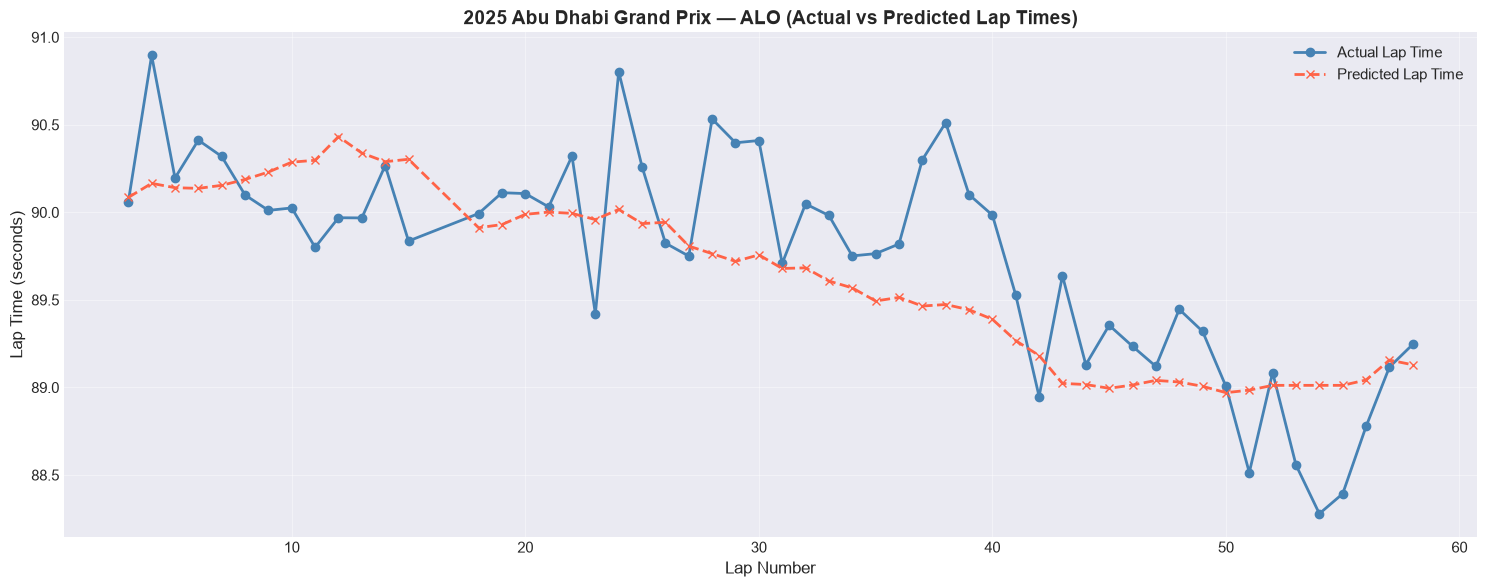

Saved: 11_2025_race_simulation.png

Lap-by-lap breakdown for ALO at Abu Dhabi Grand Prix (First 15 laps):


,LapNumber,Compound,tyre_life,position,actual_s,predicted_s,abs_error
49,3.0,MEDIUM,4.0,5.0,90.059,90.085,0.026
50,4.0,MEDIUM,5.0,6.0,90.896,90.165,0.731
51,5.0,MEDIUM,6.0,6.0,90.196,90.140,0.056
52,6.0,MEDIUM,7.0,6.0,90.412,90.137,0.275
53,7.0,MEDIUM,8.0,6.0,90.319,90.154,0.165
54,8.0,MEDIUM,9.0,6.0,90.099,90.188,0.089
55,9.0,MEDIUM,10.0,6.0,90.011,90.230,0.219
56,10.0,MEDIUM,11.0,6.0,90.025,90.286,0.261
57,11.0,MEDIUM,12.0,6.0,89.800,90.297,0.497
58,12.0,MEDIUM,13.0,6.0,89.969,90.432,0.463


In [54]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 13: 2025 Race Simulation (Actual vs Predicted)
# ─────────────────────────────────────────────────────────────────────────────

# Pick a specific 2025 race (the first one available in the test set)
if len(test_df) > 0:
    sample_race = test_df['GrandPrix'].iloc[0]
    race_df = test_df[test_df['GrandPrix'] == sample_race].copy()
    
    # Pick a top driver to visualize (e.g., the one who completed the most laps)
    driver_laps = race_df.groupby('Driver').size()
    target_driver = driver_laps.idxmax()
    
    driver_race_df = race_df[race_df['Driver'] == target_driver].sort_values('LapNumber')
    
    plt.figure(figsize=(15, 6))
    plt.plot(driver_race_df['LapNumber'], driver_race_df['actual_s'], marker='o', label='Actual Lap Time', color='steelblue', linewidth=2)
    plt.plot(driver_race_df['LapNumber'], driver_race_df['predicted_s'], marker='x', label='Predicted Lap Time', color='tomato', linewidth=2, linestyle='--')
    
    plt.title(f'2025 {sample_race} — {target_driver} (Actual vs Predicted Lap Times)', fontsize=14, fontweight='bold')
    plt.xlabel('Lap Number', fontsize=12)
    plt.ylabel('Lap Time (seconds)', fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/11_2025_race_simulation.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: 11_2025_race_simulation.png')
    
    # Print lap-by-lap table for the first 15 laps
    display_cols = ['LapNumber', 'Compound', 'tyre_life', 'position', 'actual_s', 'predicted_s', 'abs_error']
    display_df = driver_race_df[display_cols].head(15).round(3)
    print(f"\nLap-by-lap breakdown for {target_driver} at {sample_race} (First 15 laps):")
    display(display_df)
else:
    print("No 2025 test data available to simulate.")
